# MAGIC dataset

In [ ]:
#to do: check early stopping everywhere?

## Import libraries and load MAGIC dataset

In [ ]:
!pip install optuna
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00


In [ ]:
#TO RUN
import math
import time
import numpy as np
import pandas as pd
import random as rnd
from matplotlib import pyplot as plt

from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap
import optuna

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GaussianNoise, Input
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import AUC

from optuna.visualization import plot_optimization_history
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, precision_recall_curve, f1_score, auc
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    log_loss
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
#from sklearn.calibration import CalibratedClassifierCV
#from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import joblib
import os
import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names") # to silence harmless LightGBM warning

In [ ]:
def update_elapsed(key, value):
    fname = 'elapsed_times.pkl'
    times = joblib.load(fname) if os.path.exists(fname) else {}
    times[key] = value
    joblib.dump(times, fname)

In [ ]:
#TO RUN

# ============================================================
# LOAD previously saved objects (no retraining needed)
# ============================================================

# --- Trained models ---
rf                = joblib.load('rf_baseline.pkl')
best_gbm          = joblib.load('gbm_tuned.pkl')
best_model_xgb    = joblib.load('xgb_tuned.pkl')
final_model_cb    = joblib.load('catboost_tuned.pkl')
final_model_lgb   = joblib.load('lightgbm_tuned.pkl')
simple_nn         = keras.models.load_model('nn_model.h5')
nn_final = joblib.load('nn_final.pkl')
history = nn_final['history']

# --- Optuna studies ---
study_gbm = joblib.load('study_gbm.pkl')
study_xgb = joblib.load('study_xgb.pkl')
study_cb  = joblib.load('study_cb.pkl')
study_lgb = joblib.load('study_lgb.pkl')
study_nn  = joblib.load('study_nn.pkl')

# --- Clean metrics ---
clean_metrics = joblib.load('clean_metrics.pkl')
roc_auc_clean_rf, acc_clean_rf, err_clean_rf = (
    clean_metrics['rf']['auc'], clean_metrics['rf']['acc'], clean_metrics['rf']['err'])
roc_auc_clean_gbm, acc_clean_gbm, err_clean_gbm = (
    clean_metrics['gbm']['auc'], clean_metrics['gbm']['acc'], clean_metrics['gbm']['err'])
roc_auc_clean_xgb, acc_clean_xgb, err_clean_xgb = (
    clean_metrics['xgb']['auc'], clean_metrics['xgb']['acc'], clean_metrics['xgb']['err'])
roc_auc_clean_cb, acc_clean_cb, err_clean_cb = (
    clean_metrics['cb']['auc'], clean_metrics['cb']['acc'], clean_metrics['cb']['err'])
roc_auc_clean_lgb, acc_clean_lgb, err_clean_lgb = (
    clean_metrics['lgb']['auc'], clean_metrics['lgb']['acc'], clean_metrics['lgb']['err'])
roc_auc_clean_nn = clean_metrics['nn']['auc']

# --- Best hyperparameters ---
best_params = joblib.load('best_params.pkl')
best_model_xgb = best_params['xgb']
final_model_cb = best_params['cat']
final_model_lgb = best_params['lgb']
best_nn_params = joblib.load('best_nn_params.pkl')

# --- Learning curve ---
lc = joblib.load('learning_curve_results.pkl')
train_sizes = lc['train_sizes']
lc_auc_xgb, lc_auc_cat, lc_auc_lgb, lc_auc_nn = (
    lc['lc_auc_xgb'], lc['lc_auc_cat'], lc['lc_auc_lgb'], lc['lc_auc_nn'])

# --- Feature noise robustness ---
feat = joblib.load('feature_noise_results.pkl')
noise_levels_feat = feat['noise_levels_feat']
auc_drop_xgb_feat = feat['auc_drop_xgb_feat']
auc_drop_cb_feat  = feat['auc_drop_cb_feat']
auc_drop_lgb_feat = feat['auc_drop_lgb_feat']
auc_drop_nn_feat  = feat['auc_drop_nn_feat']

# --- Label noise robustness ---
lab = joblib.load('label_noise_results.pkl')
noise_levels_lab = lab['noise_levels_lab']
auc_drop_xgb_lab = lab['auc_drop_xgb_lab']
auc_drop_cb_lab  = lab['auc_drop_cb_lab']
auc_drop_lgb_lab = lab['auc_drop_lgb_lab']
auc_drop_nn_lab  = lab['auc_drop_nn_lab']


# --- SHAP ---
explainer_xgb = joblib.load('shap_explainer_xgb.pkl')
shap_data = joblib.load('shap_feature_importance.pkl')
feature_names = shap_data['feature_names']
mean_abs_shap_rf  = shap_data['rf_shap_mean_abs']
mean_abs_shap_xgb = shap_data['xgb_shap_mean_abs']
mean_abs_shap_cb  = shap_data['cb_shap_mean_abs']
mean_abs_shap_nn  = shap_data['nn_shap_mean_abs']
shap_values_rf  = shap_data['shap_values_rf']
shap_values_xgb = shap_data['shap_values_xgb']
shap_values_cb  = shap_data['shap_values_cb']
shap_values_nn  = shap_data['shap_values_nn']
shap_importance_norm = joblib.load('shap_importance_norm.pkl')

# --- Feature elimination ---
fe = joblib.load('feature_elimination_results.pkl')
n_dropped_list = fe['n_dropped_list']
results_drop   = fe['results_drop']

# --- Other ---
results = joblib.load('xgb_one_at_a_time_results.pkl')
params_to_test = {k: data['values'] for k, data in results.items()}
# --- Elapsed times (unpack from single dict) ---


# --- Elapsed times (safe unpack) ---
# sets variable to zero if not yet saved
elapsed_times = joblib.load('elapsed_times.pkl')
elapsed_rf        = elapsed_times.get('rf_train', 0)
elapsed_gbm       = elapsed_times.get('gbm_optuna', 0)
elapsed_xgb       = elapsed_times.get('xgb_optuna', 0)
elapsed_cb        = elapsed_times.get('cb_optuna', 0)
elapsed_lgb       = elapsed_times.get('lgb_optuna', 0)
elapsed_nn_tune   = elapsed_times.get('nn_optuna', 0)
elapsed_nn        = elapsed_times.get('nn_final', 0)
elapsed_red       = elapsed_times.get('learning_curve', 0)
elapsed_feat      = elapsed_times.get('feature_noise', 0)
elapsed_lab       = elapsed_times.get('label_noise', 0)
elapsed_feats_el  = elapsed_times.get('feature_elim', 0)
elapsed_target_feat = elapsed_times.get('targeted_feature_noise', 0)
elapsed_noisy_test  = elapsed_times.get('noisy_test', 0)

# --- Targeted noise on top features ---
targeted_noise = joblib.load('targeted_noise_results.pkl')
noise_levels_target   = targeted_noise['noise_levels_target']
auc_drop_xgb_target   = targeted_noise['auc_drop_xgb_target']
auc_drop_cb_target    = targeted_noise['auc_drop_cb_target']
auc_drop_lgb_target   = targeted_noise['auc_drop_lgb_target']
auc_drop_nn_target    = targeted_noise['auc_drop_nn_target']
elapsed_target_feat   = targeted_noise['elapsed_target_feat']
top_3_indices         = targeted_noise['top_3_indices']
top_3_names           = targeted_noise['top_3_names']

# NN final results (roc_auc_clean_nn, history, etc.) already loaded above; but if you need the NN final history again:
nn_final = joblib.load('nn_final.pkl')
roc_auc_clean_nn = nn_final['roc_auc_clean_nn']   # overwrite?

# --- Noisy test robustness ---
noisy_test = joblib.load('noisy_test_results.pkl')
noise_levels_noisy_test = noisy_test['noise_levels_noisy_test']
auc_drop_xgb_ntest = noisy_test['auc_drop_xgb_ntest']
auc_drop_cb_ntest  = noisy_test['auc_drop_cb_ntest']
auc_drop_lgb_ntest = noisy_test['auc_drop_lgb_ntest']
auc_drop_nn_ntest  = noisy_test['auc_drop_nn_ntest']
elapsed_noisy_test = noisy_test['elapsed_noisy_test']

rf_runs = joblib.load('rf_runs.pkl')
aucs_rf_all = rf_runs['aucs']
accs_rf_all = rf_runs['accs']
errs_rf_all = rf_runs['errs']

print("All objects loaded successfully.")

We use the [MAGIC dataset](https://archive.ics.uci.edu/dataset/159/magic+gamma+telescope), a benchmark Machine learning binary classification task.

Each sample presents 10 geometrical features calculated from an individual (preprocessed) image of the hadronic "shower" recorded (in UV wavelength) by a ground-based telescope. (Typically, the image of a shower after some pre-processing is an elongated cluster). The task consists in classifying each shower (sample) as either caused by a high-energy gamma ray (signal) or a generic cosmic ray (background) colliding with particles in Earth's upper atmosphere. (All samples in this datasets are generated via Monte Carlo methods, and SNR is higher than in real life as to make the classification task easier).

In [ ]:
# TO RUN

def load_dataset(filename):
    data_train = pd.read_csv(filename,sep=",", names = [
    'fLength', 'fWidth', 'fSize', 'fConc', 'fConc1',
    'fAsym', 'fM3Long', 'fM3Trans', 'fAlpha', 'fDist', 'class'
    ])
    #permute the data
    data_train = data_train.sample(frac=1).reset_index(drop=True) # shuffle the data
    X = data_train.iloc[:, 0:10].values # Get first two columns as the input
    Y = data_train.iloc[:, 10].values # Get the third column as the label
    Y[Y=="g"]=1
    Y[Y=="h"]=0
    Y = Y.astype(int)
    return X,Y

feature_names = ['fLength','fWidth','fSize','fConc','fConc1',
                 'fAsym','fM3Long','fM3Trans','fAlpha','fDist']

# Load the dataset
X, Y = load_dataset("https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data")

# Division between test and train dataset
rng = rnd.Random(42)
idx = list(range(X.shape[0]))
test_idx = rng.sample(idx, int(X.shape[0]*0.25))
train_idx = [i for i in idx if i not in test_idx]
X_training = X[train_idx]
X_test  = X[test_idx]
Y_training = Y[train_idx]
Y_test  = Y[test_idx]

# Validation set definition
idx = list(range(X_training.shape[0]))
val_idx = rng.sample(idx, int(X_training.shape[0]*0.25))
train_idx = [i for i in idx if i not in val_idx]
X_val  = X_training[val_idx]
X_training = X_training[train_idx]
Y_val  = Y_training[val_idx]
Y_training = Y_training[train_idx]

ratio = float(np.sum(Y_training == 0)) / np.sum(Y_training == 1) # unbalance between samples of different classes

In [ ]:
print(1/ratio) # optimal value of scale_pos_weight (see later)

1.8753023380811609


## Hyperparameters optimization for boosted forest models

### Random forest classifier for baseline comparison

As a baseline for our experiments, we use a Random forest classifier with default hyperparameters; to have some statistical significance, we fit it 50 times to the training set.

In [ ]:
# to do: run again??

# ---- Random Forest baseline (50 random seeds, keep best) ----
n_runs = 50
aucs_rf, accs_rf, errs_rf = [], [], []
best_rf = None
best_auc = -1.0
best_idx = -1

i = time.time()
for seed in range(n_runs):
    rf_temp = RandomForestClassifier(random_state=seed, n_jobs=-1)
    rf_temp.fit(X_training, Y_training)
    y_prob = rf_temp.predict_proba(X_test)[:, 1]
    y_pred = rf_temp.predict(X_test)
    auc = roc_auc_score(Y_test, y_prob)
    acc = accuracy_score(Y_test, y_pred)
    err = 1 - acc
    aucs_rf.append(auc)
    accs_rf.append(acc)
    errs_rf.append(err)
    if auc > best_auc:
        best_auc = auc
        best_rf = rf_temp
        best_idx = seed

elapsed_rf = time.time() - i
rf = best_rf
roc_auc_clean_rf = aucs_rf[best_idx]
acc_clean_rf = accs_rf[best_idx]
err_clean_rf = errs_rf[best_idx]

print(f"RF ({n_runs} runs) completed in {elapsed_rf:.1f}s")
print(f"Best run (seed={best_idx}): AUC={roc_auc_clean_rf:.4f}, Acc={acc_clean_rf:.4f}, 0-1 Loss={err_clean_rf:.4f}")
print(f"Mean AUC: {np.mean(aucs_rf):.4f} ± {np.std(aucs_rf):.4f}")

# Dump best model and full run history
joblib.dump(rf, 'rf_baseline.pkl')

RF (50 runs) completed in 258.0s
Best run (seed=47): AUC=0.9439, Acc=0.8812, 0-1 Loss=0.1188
Mean AUC: 0.9412 ± 0.0008


['rf_baseline.pkl']

In [ ]:
joblib.dump(rf,               'rf_baseline.pkl')
joblib.dump({'aucs': aucs_rf, 'accs': accs_rf, 'errs': errs_rf, 'best_idx': best_idx, 'elapsed': elapsed_rf},
            'rf_runs.pkl')

['rf_runs.pkl']

### Gradient Boost

Standard gradient boosting is a tree-based binary classification model that uses _boosting_, _i.e._ it sequentially adds decision trees, each correcting the residuals of the previous ensemble.

It offers classic hyperparameters that control complexity and speed:
* `n_estimators`: number of boosting stages (trees). More trees increase capacity but may overfit
* `learning_rate`: multiplicative factor (step size) that shrinks the contribution of each new tree before adding it to the ensemble; lower values demand more iterations but often generalize better`
* `max_depth`: maximum depth of each tree; deeper trees capture more interactions but overfit easily
* `subsample`: fraction of samples used for fitting each tree (stochastic gradient boosting). Values < 1.0 add randomness and can improve generalization
* `max_features`: fraction of features considered when looking for the best split
* `min_samples_split` and `min_samples_leaf`: minimum number of samples required to split an internal node or to be at a leaf node; both act as regularizers
* `class_weight`: to account for imbalance between classes.

We optimize these using Optuna (see below for the explanation) with 5‑fold stratified cross validation (CV) using 0-1 loss, and evaluate using ROC‑AUC score.

For this problem we use ROC-AUC score (_Receiver Operating Characteristic - Area Under Curve_), a metric for binary classifiers, for validating and testing results.
It is defined as the area under the curve of true positives rate as a function of false positive rates; therefore, it penalizes false positives. In our case this is necessary, as classifying background as signal is considered worse, from a scientific point of view, than missing out on a real signal.
ROC-AUC varies from 0 to 1, 1 with 1 being perfect classification and 0.5 a random guess.

In practice, for tree models, given a set of predicted probabilities of the sample belonging to class 1 (which range continuously from 0 to 1), and the corresponding true labels of the samples, this curve is computed by varying the _decision threshold_ of the model, _i.e._ the threshold above which a sample is classified as belonging to class 1 (and not to class 0), for the simple reason that by doing so the false positive rate can change from 0 to 1.

In [ ]:
def objective(trial):
    #scale_pos_weight = trial.suggest_float('scale_pos_weight', 0.5, 1.5, log=True) # note: defined by us

    params = {
        'loss': 'log_loss',
        'random_state': 42,
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),          # reduced range
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        #'class_weight': {0: 1.0, 1: scale_pos_weight},

        # early stopping using loss - no simple way to use ROCAUC here
        'validation_fraction': 0.1,   # hold out 10% of each fold's training data
        'n_iter_no_change': 10,       # stop if no improvement for 10 iterations
        'tol': 1e-4,                  # minimum required improvement
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]
        model = GradientBoostingClassifier(**params)
        model.fit(X_tr, y_tr)
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))
    return np.mean(scores)

study_gbm = optuna.create_study(direction='maximize')

[I 2026-05-19 09:26:40,038] A new study created in memory with name: no-name-27d39e03-fc93-4380-9ddc-72070ffa5692


In [ ]:
i=time.time()
study_gbm.optimize(objective, n_trials=50, show_progress_bar=True)
f=time.time()
elapsed_gbm=f-i
print(f"Training completed in {elapsed_gbm:.1f} seconds.")

# Final training with best params + early stopping
best_gbm = GradientBoostingClassifier(
    loss='log_loss',
    random_state=42,
    validation_fraction=0.2,
    n_iter_no_change=10,        # stop early if no gain
    tol=1e-4,
    **study_gbm.best_params
)
best_gbm.fit(X_training, Y_training)

y_pred_gbm = best_gbm.predict(X_test)
y_prob_gbm = best_gbm.predict_proba(X_test)[:, 1]
roc_auc_clean_gbm=roc_auc_score(Y_test, y_prob_gbm)
acc_clean_gbm=accuracy_score(Y_test, y_pred_gbm)
err_clean_gbm=1-acc_clean_gbm

print(f"GradientBoosting Test AUC: {roc_auc_clean_gbm:.4f}")

roc_auc_clean_gbm=roc_auc_score(Y_test, y_prob_gbm)

  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-19 09:26:59,124] Trial 0 finished with value: 0.9290176112106423 and parameters: {'n_estimators': 237, 'learning_rate': 0.06619586221226299, 'max_depth': 9, 'subsample': 0.517311176646325, 'max_features': 0.5902368072361366, 'min_samples_split': 6, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.9290176112106423.
[I 2026-05-19 09:27:10,861] Trial 1 finished with value: 0.9272030600660077 and parameters: {'n_estimators': 114, 'learning_rate': 0.12554059032178566, 'max_depth': 6, 'subsample': 0.6306980863792679, 'max_features': 0.5655186474718925, 'min_samples_split': 15, 'min_samples_leaf': 17}. Best is trial 0 with value: 0.9290176112106423.
[I 2026-05-19 09:27:29,382] Trial 2 finished with value: 0.9183036497651272 and parameters: {'n_estimators': 56, 'learning_rate': 0.010124518992256717, 'max_depth': 9, 'subsample': 0.8755672569558344, 'max_features': 0.6341908084656418, 'min_samples_split': 18, 'min_samples_leaf': 15}. Best is trial 0 with value: 0.9290176112106423

In [ ]:
elapsed_gbm=2260 # calculated by hand because of a bug
print(f"Training completed in {elapsed_gbm} seconds.")

Training completed in 2260 seconds.


We plot the "functional ANOVA" score, _i.e._ the fraction of total variance explained by each hyperparameter, which is readily available in Optuna. We note above all the importance of learning rate.

In [ ]:

# TO RUN
#VISUALISE PARAMETER IMPORTANCE
optuna.visualization.plot_param_importances(study_gbm).show()

In [ ]:
joblib.dump(best_gbm,         'gbm_tuned.pkl')
joblib.dump(study_gbm, 'study_gbm.pkl')

['study_gbm.pkl']

Note: from here on we use Colab's virtual machine's GPU for faster computation time (GradientBoostingClassifier is not optimized for GPU usage, so we had to use CPU).

### XGBoost

XGBoost is a boosted tree-based classification model that, as an improvement of standard Gradient Boosting, makes use of regularization, pruning, and second derivatives of the loss function (for evaluating the best split), along with other algorithmic improvements aimed at improving classification accuracy.

With regard to computational complexity, training is made much faster by parallel evaluation of all features, histogram-based splitting (_i.e._ continuous features are discretised by means of a certain number of bins), cache-friendly storage of intermediate results, and the fact that the code is written in C++ (instead of standard Python / CPython like Gradient Boost).

The hyperparameters involved in this model are:

- `max_depth`: same as before (GradientBoost)
- `min_child_weight`: parameter to regulate the minimum amount of points needed to add another node to the decision tree; regulates overfitting by avoiding to split over very small groups of points (same as `min_samples_split` in GradientBoost)
- `learning rate`: same as before
- `n_estimators`: samea as before
- `subsample` and `colsample_bytree`: percentage of rows (samples) or of columns (features) used by each tree, with a similar concept used in random forests with _bagging_. Same to, respectively, `subsample` and `max_features` in GradientBoost
- `gamma`: parameter to regulate _pruning_; with a high value the code will favor a simpler solution rather then a slightly more accurate one
- `reg_lambda`: parameter to regulate model complexity - it is the multiplicative constant of the L-2 regularization term
- `scale_pos_weight`: weight for the positive class; compensates for class imbalance by up-weighting the minority class

#### Performance with basic hyperparameters

In [ ]:
print(xgb.build_info()['USE_CUDA'])

True


In [ ]:
# Parameters configuration
model = xgb.XGBClassifier(
    booster="gbtree",            # weak learner used as a base
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=5,                 # depth of trees
    subsample=0.8,               # 80% of rows
    colsample_bytree=0.8,        # 80% of columns
    scale_pos_weight=ratio,      # parameter that accounts for the inbalance of classes
    objective='binary:logistic', # goal of the model
    n_jobs=-1,                   # uses all cpu cores
    eval_metric='auc',           # metric used
    early_stopping_rounds=50,    # number of iteration that takes to stop if there are no significant improvements
    tree_method="hist",
    device='cuda',
    enable_categorical=True
)

In [ ]:
# Training
model.fit(
    X_training, Y_training,
    eval_set=[(X_training, Y_training), (X_val, Y_val)], # evaluate also (but not only) on training set to have better understanding
    verbose=100
)

[0]	validation_0-auc:0.87878	validation_1-auc:0.86099
[100]	validation_0-auc:0.94881	validation_1-auc:0.92154
[200]	validation_0-auc:0.96462	validation_1-auc:0.92623
[300]	validation_0-auc:0.97489	validation_1-auc:0.92839
[355]	validation_0-auc:0.97948	validation_1-auc:0.92787


XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device='cuda', early_stopping_rounds=50,
              enable_categorical=True, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
# Evaluation
y_pred_basic_xgb = model.predict(X_test)
y_prob_basic_xgb = model.predict_proba(X_test)[:, 1]
roc_auc_clean_basic_xgb=roc_auc_score(Y_test, y_prob_basic_xgb)

/usr/local/lib/python3.12/dist-packages/xgboost/core.py:751: UserWarning:

[10:07:40] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.




In [ ]:
print("Classification Report")
print(classification_report(Y_test, y_pred_basic_xgb))
print(f"ROC AUC Score: {roc_auc_clean_basic_xgb:.4f}")

Classification Report
              precision    recall  f1-score   support

           0       0.84      0.82      0.83      1695
           1       0.90      0.91      0.91      3060

    accuracy                           0.88      4755
   macro avg       0.87      0.86      0.87      4755
weighted avg       0.88      0.88      0.88      4755

ROC AUC Score: 0.9413


#### Performance analysis for different hyperparameters - one-at-a-time search
Strategy (simplistic): change one parameter at a time, keep others as the default; use K-fold cross validation.

In [ ]:
# Base parameters
base_params = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'n_jobs': -1,
    'scale_pos_weight': ratio,
    'tree_method': 'hist',
    'device': 'cuda',
    'eval_metric': 'auc',
    'verbosity': 0,
    # Defaults for parameters we aren't testing
    'n_estimators': 500,
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'reg_lambda': 1
}

# Parameters to analyze
params_to_test = {
    'gamma': [0, 0.1, 0.5, 1, 2, 5],
    'reg_lambda': [0.1, 1, 10, 50, 100],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'n_estimators': [100, 300, 500, 800, 1000]
}


results = {} # To store the results

In [ ]:
# setting up optimized library for K folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
for param_name, param_values in params_to_test.items():
    print(f"Testing {param_name}...", end=" ")
    means = []
    stds = []

    for value in param_values:
        # Update params
        current_params = base_params.copy()
        current_params[param_name] = value        # uses default parameters for the rest and changes only one parameter

        # Train & CV
        model = xgb.XGBClassifier(**current_params)
        scores = cross_val_score(model, X_training, Y_training, cv=cv_strategy, scoring='roc_auc')

        means.append(scores.mean())
        stds.append(scores.std())

    # Save data for plotting
    results[param_name] = {
        'values': param_values,
        'means': means,
        'stds': stds
    }
    print("Done.")


Testing gamma... Done.
Testing reg_lambda... Done.
Testing learning_rate... Done.
Testing subsample... Done.
Testing colsample_bytree... Done.
Testing max_depth... Done.
Testing n_estimators... Done.


In [ ]:
params_to_test = {k: data['values'] for k, data in results.items()}

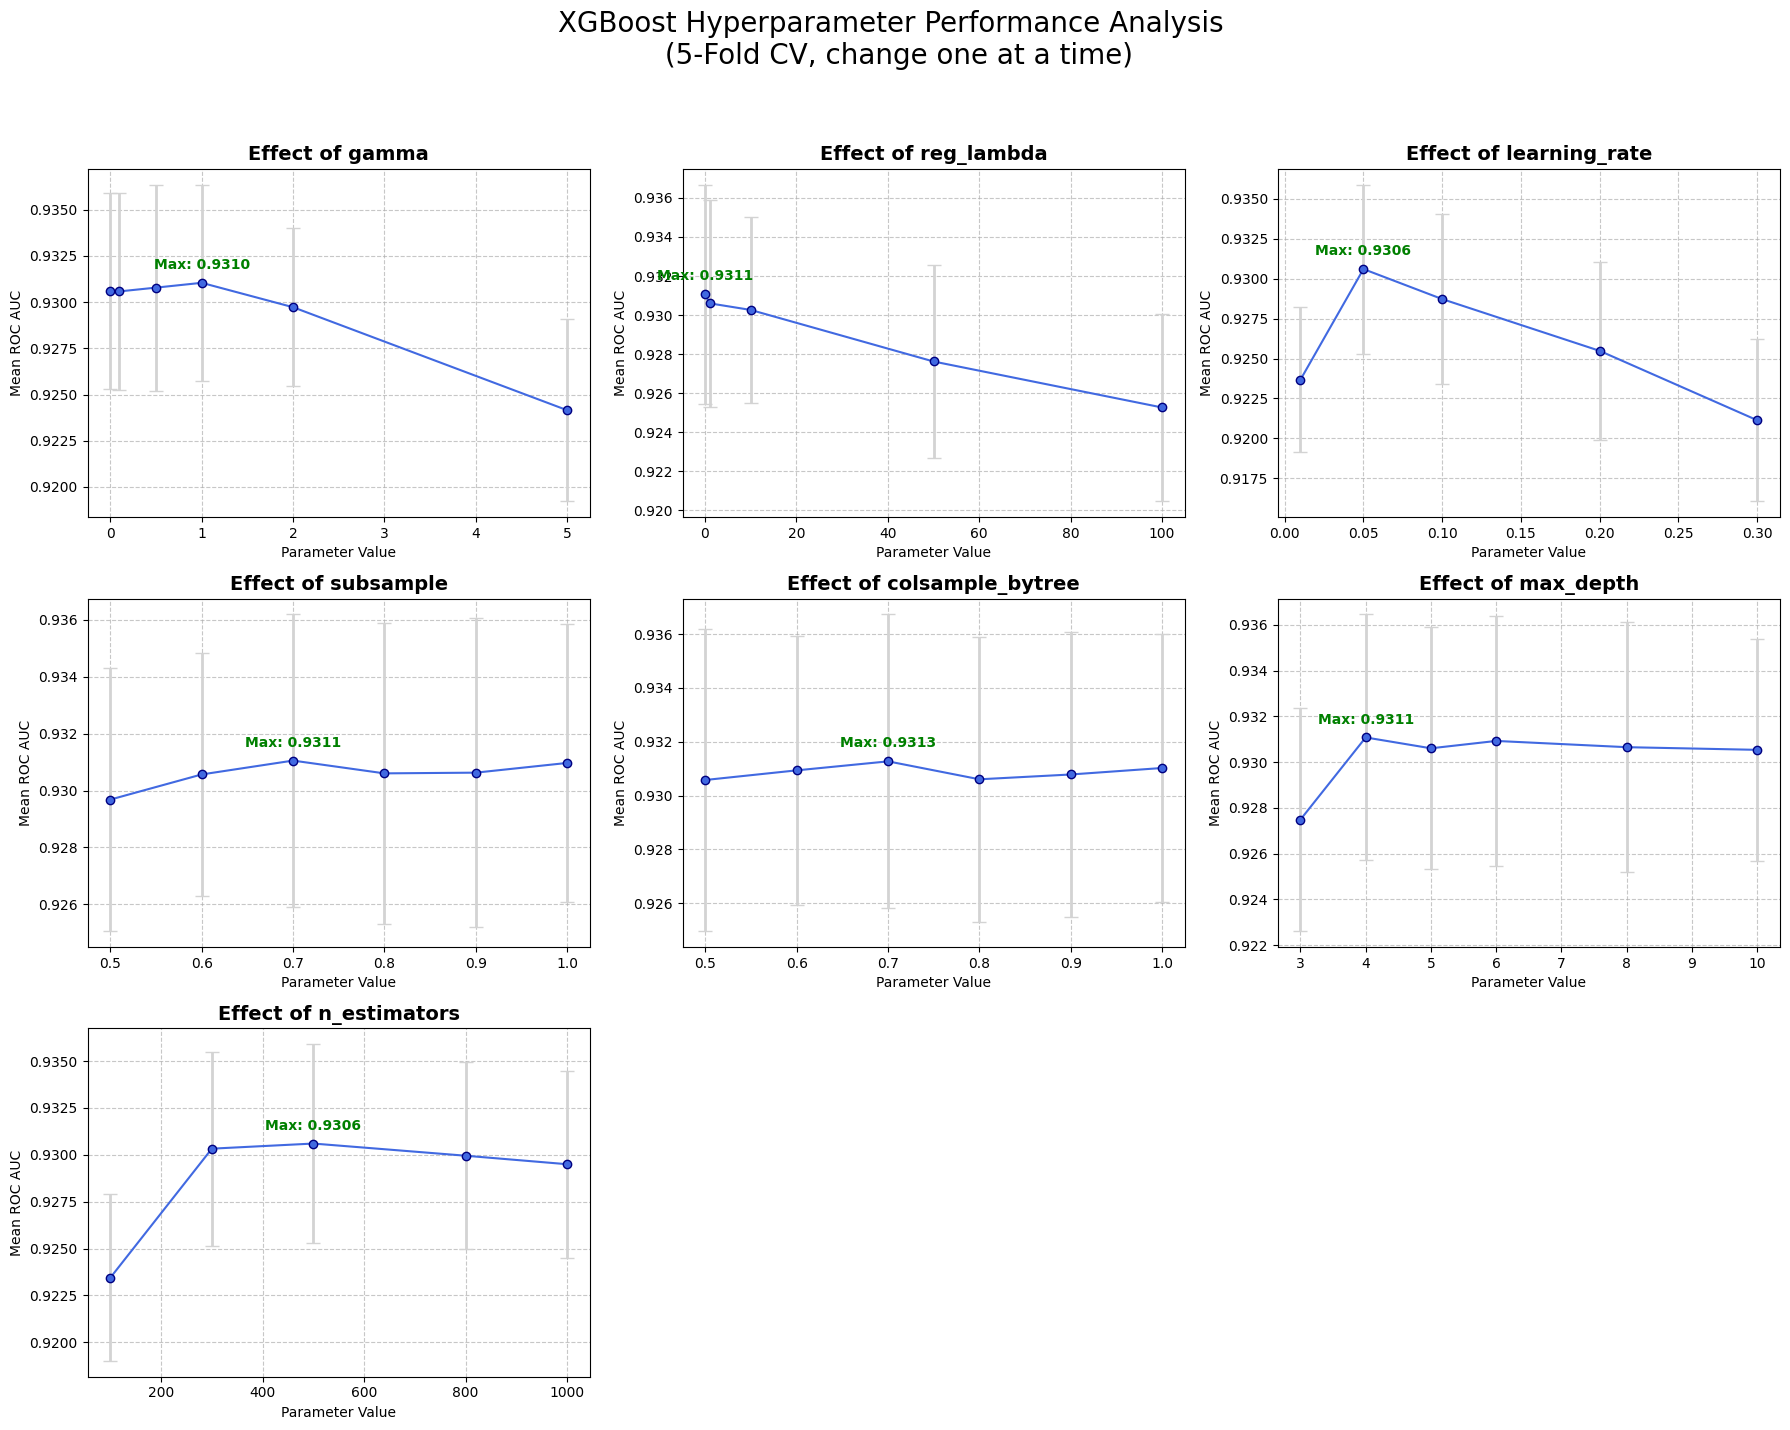

In [ ]:
#TO RUN
#PLOT RESULTS

# Calculate grid size
n_params = len(params_to_test)
n_cols = 3
n_rows = math.ceil(n_params / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows)) #fix window to fit the plots
fig.suptitle('XGBoost Hyperparameter Performance Analysis \n (5-Fold CV, change one at a time)', fontsize=20)
axes = axes.flatten() # Flatten 2D array to 1D for easy iteration

for i, (param_name, data) in enumerate(results.items()):
    ax = axes[i]

    # Extract data
    x_vals = data['values']
    y_means = data['means']
    y_errs = data['stds']

    # Plot Error Bar
    ax.errorbar(x_vals, y_means, yerr=y_errs, fmt='-o', capsize=5,
                color='royalblue', ecolor='lightgray', elinewidth=2, markeredgecolor='navy')
    # error bars are standard deviation on the hyperparameter value (each has number of folds samples)

    # Styling
    ax.set_title(f'Effect of {param_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Parameter Value', fontsize=10)
    ax.set_ylabel('Mean ROC AUC', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.7)

    # Highlight the max value
    max_idx = np.argmax(y_means)
    ax.annotate(f'Max: {y_means[max_idx]:.4f}',
                xy=(x_vals[max_idx], y_means[max_idx]),
                xytext=(0, 10), textcoords='offset points', ha='center',
                color='green', fontweight='bold')
for ax in axes[len(results):]:
    fig.delaxes(ax)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit title
plt.show()

In [ ]:
# to do: run multiple times to get smaller uncertainty?

In [ ]:
# TRAINING ON BEST FOUND PARAMETERS
print("FINAL ANALYSIS: COMBINING BEST PARAMETERS")

# Extract best parameters automatically from results
best_found_params = base_params.copy() # Start with base defaults

print("Best parameters found individually:")
for param_name, data in results.items():
    # Find index of maximum Mean AUC
    best_idx = np.argmax(data['means'])
    best_value = data['values'][best_idx]
    best_score = data['means'][best_idx]

    # Update the best params dictionary
    best_found_params[param_name] = best_value

    print(f"  - {param_name}: {best_value} (AUC: {best_score:.4f})")

print("\nFull configuration for final model:")
print(best_found_params)

# Train on the WHOLE dataset (Production Ready)
print("\nTraining final model on full dataset...")

final_model = xgb.XGBClassifier(**best_found_params)
final_model.fit(X_training, Y_training)


# Final Evaluation on Test Set
print("FINAL TEST SET PERFORMANCE")

# Final predictions
y_pred_grid_xgb = final_model.predict(X_test) # of grid search optimized XGB
y_prob_grid_xgb = final_model.predict_proba(X_test)[:, 1] # of grid search optimized XGB

# Calculate accuracy for more clear results
acc_grid_xgb = accuracy_score(Y_test, y_pred_grid_xgb)
zero_one_grid_xgb = 1 - acc_grid_xgb

# Final AUC score for comparison
roc_auc_grid_xgb = roc_auc_score(Y_test, y_prob_grid_xgb) # of grid search optimized XGB

print(f"Final Test ROC AUC:  {roc_auc_grid_xgb:.4f}")
print(f"Final Test Accuracy: {acc_grid_xgb:.4f}")
print(f"Final Test 0-1 Loss: {zero_one_grid_xgb:.4f} (Error Rate)")

# Number of missclassified events
n_errors = int(zero_one_grid_xgb * len(Y_test))
print(f"\nTotal misclassified samples: {n_errors} out of {len(Y_test)}")

FINAL ANALYSIS: COMBINING BEST PARAMETERS
Best parameters found individually:
  - gamma: 1 (AUC: 0.9310)
  - reg_lambda: 0.1 (AUC: 0.9311)
  - learning_rate: 0.05 (AUC: 0.9306)
  - subsample: 0.7 (AUC: 0.9311)
  - colsample_bytree: 0.7 (AUC: 0.9313)
  - max_depth: 4 (AUC: 0.9311)
  - n_estimators: 500 (AUC: 0.9306)

Full configuration for final model:
{'booster': 'gbtree', 'objective': 'binary:logistic', 'n_jobs': -1, 'scale_pos_weight': np.float64(0.5332473488105475), 'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'auc', 'verbosity': 0, 'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.7, 'colsample_bytree': 0.7, 'gamma': 1, 'reg_lambda': 0.1}

Training final model on full dataset...
FINAL TEST SET PERFORMANCE
Final Test ROC AUC:  0.9409
Final Test Accuracy: 0.8784
Final Test 0-1 Loss: 0.1216 (Error Rate)

Total misclassified samples: 577 out of 4755


In [ ]:
joblib.dump(results, 'xgb_one_at_a_time_results.pkl')

['xgb_one_at_a_time_results.pkl']

#### Performance analysis for different parameters - grid search (using Optuna)
Strategy (more encompassing): explore points in hyperparameter space in search of optimum combination. Repeat for a number of trials. Optimization is done via [_Tree structured Parzen Estimator_ (TPE) algorithm](https://arxiv.org/pdf/2304.11127), which is implemented in the "Optuna" module.

On each trial, TPE fits one Gaussian Mixture Model (GMM) $l(x)$ (_i.e._ a Kernel Density Estimate of the true probability distribution of hyperparameter values, where the basis consists of Gaussian functions) to the set of hyperparameter values associated with the best objective values; and another GMM $g(x)$ to the remaining hyperparameter values. It chooses the hyperparameter value $x$ that maximizes the ratio $\frac{l(x)}{g(x)}$. It can be proven that maximizing this ratio is (approximately) equivalent to minimizing the quantile-evidence of the model, $\int_{-\infty}^{y^{\gamma}} p(y|x,D) \, dy$ (where $D$ is a set of $x-y$ observations and $y$ an observation of the objective function). The proof relies on Bayes' theorem and on the assumption that a "better" subset of hyperhyperparameters $D^{l}$ exists such that the likelihood $p(x|y,D)$ is equal to $p(x|D^{l})$ for $y$ in the top gamma quantile of observations, $y \leq y^{\gamma}$. Note that the evaluation of the objective (or "loss") function, here, is expensive as it involves training the model with the given hyperparameters: for this reason, it would be computationally unfeasible to use a gradient descent method. Because of the algorithm relying on these successive "splits" in hyperparameter space, it is said to have a "tree-like" structure.

We use 0-1 loss as metric, as ROC-AUC is not a differentiable loss function, so it can only be used as an evaluation metric.

##### Setup

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'booster': 'gbtree',
        'objective': 'binary:logistic',
        'n_jobs': -1,
        #'scale_pos_weight': ratio,
        'tree_method': 'hist',
        'device':'cuda',
        'verbosity': 0,
        'early_stopping_rounds': 50,  # added: early stopping if loss does not improve

        # Define grid search
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 100, log=True),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.5, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 2),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]

        model = xgb.XGBClassifier(**param_space, random_state=42)
        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], verbose=False)
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))

    return np.mean(scores)

# Study execution
study_xgb = optuna.create_study(direction='maximize')

##### Optimization

In [ ]:
i=time.time()
study_xgb.optimize(objective, n_trials=50) # ie. run TPE algo for (at most) n_trials times
f=time.time()
# Final results
print("\nBest parameters found with Optuna:")
print(study_xgb.best_params)
elapsed_xgb=f-i
print(f"Training completed in {elapsed_xgb:.1f} seconds.")


Best parameters found with Optuna:
{'gamma': 0.34098869670619414, 'reg_lambda': 18.479685816615113, 'learning_rate': 0.06180236528972195, 'subsample': 0.9317257898565021, 'colsample_bytree': 0.8083130935097634, 'max_depth': 10, 'n_estimators': 1225, 'scale_pos_weight': 1.6205823989270203, 'min_child_weight': 3}
Training completed in 162.0 seconds.


In [ ]:
# TO RUN
#VISUALISE PARAMETER IMPORTANCE
optuna.visualization.plot_param_importances(study_xgb).show()

##### Train model on best hyperparameters

In [ ]:
final_params_xgb = {
    'booster': 'gbtree',
    'objective': 'binary:logistic',
    'tree_method': 'hist',
    'device':'cuda',
    'random_state': 42,
    'early_stopping_rounds': 50,   # moved here from fit()
    'eval_metric': 'auc',          # moved here from fit()
    **study_xgb.best_params
}

best_model_xgb = xgb.XGBClassifier(**final_params_xgb)
best_model_xgb.fit(
    X_training, Y_training,
    eval_set=[(X_val, Y_val)], # will be used for early stopping (so, keep even if using CV)
    verbose=False
)

# Test set evaluation
y_pred_xgb = best_model_xgb.predict(X_test)
y_prob_xgb = best_model_xgb.predict_proba(X_test)[:, 1]

roc_auc_clean_xgb = roc_auc_score(Y_test, y_prob_xgb)
acc_clean_xgb = accuracy_score(Y_test, y_pred_xgb)
err_clean_xgb = 1 - acc_clean_xgb

print(f"ROC AUC Score: {roc_auc_clean_xgb:.4f}")
print(f"Accuracy Score: {acc_clean_xgb:.4f}")
print(f"0-1 Mean Loss: {err_clean_xgb:.4f}")

ROC AUC Score: 0.9415
Accuracy Score: 0.8814
0-1 Mean Loss: 0.1186


In [ ]:
joblib.dump(best_model_xgb,   'xgb_tuned.pkl')
joblib.dump(study_xgb, 'study_xgb.pkl')

['study_xgb.pkl']

We note similar accuracy as with one-at-a-time search

### CatBoost

We try another kind of common Gradient Boosting algorithm: "Catboost". With respect to XGBoost and other Boosting alrgorithms, and without going into too much into detail, Catboost:
* builds symmetric (oblivious) trees, where the same feature and split condition are used at all nodes of a given depth. XGBoost and GradientBoost on the other hand builds asymmetric, level-wise trees, which can lead to more complex and potentially less generalizable structures
* introduces a novel approach called ["Ordered Boosting"](https://arxiv.org/pdf/1706.09516), a permutation-driven alternative designed to prevent the target leakage that can occur in standard gradient boosting algorithms
* is designed with sensible defaults and aims to require less manual tuning to achieve good performance
* can be slower to train due to its ordered boosting mechanism, but it often provides competitive or superior accuracy and is sometimes noted for faster prediction speed once trained.

The theoretical justification for this algorithm is the following. Most implementations of gradient boosting, like XGBoost and LGBoost, face the following statistical issue. A prediction model $F$ obtained after several steps of boosting relies on the targets (labels) of all training examples. This actually leads to a shift of the distribution of $F(x_k)\mid x_k$ for a training example $x_k$ from the distribution of $F(x)\mid x$ for a test example $x$. This finally leads to a _prediction shift_ of the learned model. This problem is a special kind of so-called _target leakage_, _i.e._, the use of information during model training that would not be available at prediction time.

Indeed, in most Boosted models gradients used at each step to compute the new predictor, $F_t$, are estimated using the target values of the same data points the current model $F^{t-1}$ was built on. However, the conditional distribution $F^{t-1}(x_k)\mid x_k$ for a training example $x_k$ is shifted, in general, from the distribution $F^{t-1}(x)\mid x$ for a test example $x$.

The CatBoost algorithm provides a solution to this problem (along with others, as we mentioned) by performing permutations of the training set, such that for calculating the residual on an example, we always use a model trained without it. The practical implementation is not so straightforward, but it is based on this idea.

#### Grid search (Optuna), ROC-AUC metric

The hyperparameters involved in this model are:

* `iterations`: number of boosting rounds (trees); more trees increase capacity but may overfit
*  `learning_rate`: same as XGBoost
* `depth`: same as `max_depth` for XGBoost
* `l2_leaf_reg`: same as `lambda` for XGBoost
* `random_strength`: strength of Gaussian noise added to split scores (_i.e._, the reduction in loss); acts as a regularizer by introducing randomness during tree construction
* `bootstrap_type` (Bayesian) and `bagging_temperature`: we use Bayesian bootstrap with a temperature parameter; higher temperature increases sample-weight randomness, decorrelating trees (see below)
* `colsample_bylevel`: same as `colsample_bytree` for XGBoost
* `min_data_in_leaf`: same as `min_child_weight` for XGBoost
* `scale_pos_weight`: same as for XGBoost

_Bootstrapping_ is a concept similar to subsapling, wich proved effective in practice. It assigns random weights to samples via a certain process. This is usually the heaviest part of Catboost's computation.

For Bayesian bootstrapping, each example is assigned a weight $(-\text{log}(u))^t$ where $u$ is sampled from a uniform distribution on $]0,1[$ and $t$ is the set bagging "temperature". Higher "temperature" increases weight randomness leading to more tree decorrelation, but slower training.

Here we switch back to CPU, as GPU usage is not supported for `colsample_bytree` values less than 1.

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
def objective(trial):
    param_space = {
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'task_type': 'CPU',
        'verbose': False,
        'random_seed': 42,

        # Parameters to optimize
        'iterations': trial.suggest_int('iterations', 100, 1000), # or: 100, 1000
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 1.0, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 0.01, 10.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.0, 10.0),

        'bootstrap_type': 'Bayesian', # or: 'Bernoulli'
        #'subsample': trial.suggest_float('subsample', 0.5, 1.5),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 5.0),

        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 1.5, log=True),

        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 3, 30)
    }


    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]

        model = cb.CatBoostClassifier(**param_space)
        model.fit(X_tr, y_tr, eval_set=[(X_vl, y_vl)], early_stopping_rounds= 50, verbose=False)
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))

    return np.mean(scores)

# Study execution
study_cb = optuna.create_study(direction='maximize')

In [ ]:
i=time.time()
study_cb.optimize(objective, n_trials=50) # ie. run TPE algo for (at most) n_trials times
f=time.time()
# Final results
print("\nBest parameters found with Optuna:")
print(study_cb.best_params)
elapsed_cb=f-i
print(f"Training completed in {elapsed_cb:.1f} seconds.")


Best parameters found with Optuna:
{'iterations': 847, 'learning_rate': 0.08901870269647565, 'depth': 6, 'l2_leaf_reg': 5.470990685214663, 'random_strength': 7.901740384323084, 'bagging_temperature': 0.4649572310559513, 'scale_pos_weight': 0.6737529984064896, 'colsample_bylevel': 0.8722334176078476, 'min_data_in_leaf': 9}
Training completed in 705.6 seconds.


In [ ]:
 # Training on whole set
final_model_cb = cb.CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    task_type='CPU',
    random_seed=42,
    verbose=False,
    **study_cb.best_params
)

final_model_cb.fit(
    X_training, Y_training,
    eval_set=[(X_val, Y_val)],
    early_stopping_rounds=50,
    verbose=False
)

# Test set evaluation
y_pred_cb = final_model_cb.predict(X_test)
y_prob_cb = final_model_cb.predict_proba(X_test)[:, 1]
roc_auc_clean_cb=roc_auc_score(Y_test, y_prob_cb)
acc_clean_cb=accuracy_score(Y_test, y_pred_cb)
err_clean_cb=1-acc_clean_cb

print(f"CATBOOST FINAL PERFORMANCE (TEST SET)")
print(f"ROC AUC:  {roc_auc_clean_cb:.4f}")
print(f"Accuracy: {acc_clean_cb:.4f}")
print(f"0-1 Loss: {err_clean_cb:.4f}")

CATBOOST FINAL PERFORMANCE (TEST SET)
ROC AUC:  0.9449
Accuracy: 0.8883
0-1 Loss: 0.1117


In [ ]:
joblib.dump(final_model_cb,   'catboost_tuned.pkl')
joblib.dump(study_cb,  'study_cb.pkl')

['study_cb.pkl']

In [ ]:
#TO RUN
#VISUALISE PARAMETER IMPORTANCE
optuna.visualization.plot_param_importances(study_cb).show()

### LightGMB

[LightGBM](https://www.researchgate.net/publication/378480234_LightGBM_A_Highly_Efficient_Gradient_Boosting_Decision_Tree), short for Light Gradient-Boosting Machine, is another gradient boosting library based for decision trees. The development focus however is on performance and scalability.

Its main features typical to this algorithmare _Gradient-based One-Side Sampling_ (GOSS) and _Exclusive Feature Bundling (EFB)_. With GOSS, we exclude a significant proportion of data instances with small gradients, and only use the rest to estimate the information gain. With EFB, we bundle together _mutually exclusive_ features (_i.e._, which rarely take nonzero
values simultaneously), to reduce the number of features.

Additionally, by default (and unlinke the boosted models used so far), LightGBM employs _leaf-based splits_, _i.e._ splits are computed on one leaf at a time (the one with highest gain), rather than _level-wise_, _i.e._ at each iteration a split is computed for all nodes at the same level.

LightGBM is typically the fastest to train among major boosting libraries, and its default settings often perform well without extensive tuning.

The hyperparameters involved in this model are:

- `n_estimators`: same as `iterations` in CatBoost
- `learning_rate`: same as before
- `max_depth`: same as before
- `reg_lambda`: same as before
- `min_child_samples`: same as before
- `subsample`: same as before
- `colsample_bytree`: same as before
- `scale_pos_weight`: same as before

#### Grid search (Optuna), ROC-AUC metric

In [ ]:
### LightGBM Optimisation with Optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    param_space = {
        'boosting_type': 'gbdt',
        'objective': 'binary',
        'metric': 'auc',
        'n_jobs': -1,
        'random_state': 42,
        'verbosity': -1,

        'device': 'gpu',

        # Parameters to optimize
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.001, 1.0, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 3, 50),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.5, 10.0, log=True),

        # Fixed parameters for bagging
        'bagging_freq': 1,   # perform bagging at every iteration
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    for train_idx, val_idx in cv.split(X_training, Y_training):
        X_tr, X_vl = X_training[train_idx], X_training[val_idx]
        y_tr, y_vl = Y_training[train_idx], Y_training[val_idx]

        model = lgb.LGBMClassifier(**param_space)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_vl, y_vl)],
            eval_metric='auc',
            callbacks=[lgb.early_stopping(50)]#, lgb.log_evaluation(0)]
        )
        scores.append(roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1]))

    return np.mean(scores)

# Study execution
study_lgb = optuna.create_study(direction='maximize')

i=time.time()
study_lgb.optimize(objective, n_trials=50)
f=time.time()
elapsed_lgb=f-i
print(f"Training completed in {elapsed_lgb:.1f} seconds.")

# Final results
print("Best parameters found with Optuna:")
print(study_lgb.best_params)

# Training on whole set
final_model_lgb = lgb.LGBMClassifier(**study_lgb.best_params, random_state=42, device='gpu')
final_model_lgb.fit(
    X_training, Y_training,
    eval_set=[(X_val, Y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

# Test set evaluation
y_pred_lgb = final_model_lgb.predict(X_test)
y_prob_lgb = final_model_lgb.predict_proba(X_test)[:, 1]
roc_auc_clean_lgb=roc_auc_score(Y_test, y_prob_lgb)
acc_clean_lgb=accuracy_score(Y_test, y_pred_lgb)
err_clean_lgb=1-acc_clean_lgb

print(f"LIGHTGBM FINAL PERFORMANCE (TEST SET)")
print(f"ROC AUC:  {roc_auc_clean_lgb:.4f}")
print(f"Accuracy: {acc_clean_lgb:.4f}")
print(f"0-1 Loss: {err_clean_lgb:.4f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[89]	valid_0's auc: 0.912887
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[720]	valid_0's auc: 0.922117
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[314]	valid_0's auc: 0.911669
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[733]	valid_0's auc: 0.924
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[731]	valid_0's auc: 0.926722
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[325]	valid_0's auc: 0.930842
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[335]	valid_0's auc: 0.927043
Training until validation scores don't improve for 50 rou

In [ ]:
joblib.dump(final_model_lgb,  'lightgbm_tuned.pkl')
joblib.dump(study_lgb, 'study_lgb.pkl')

['study_lgb.pkl']

In [ ]:

#TO RUN
optuna.visualization.plot_param_importances(study_lgb).show()

### Conclusions (first part of Notebook)

In the following plot we summarize the performance of the three tuned models.

to do: comment??

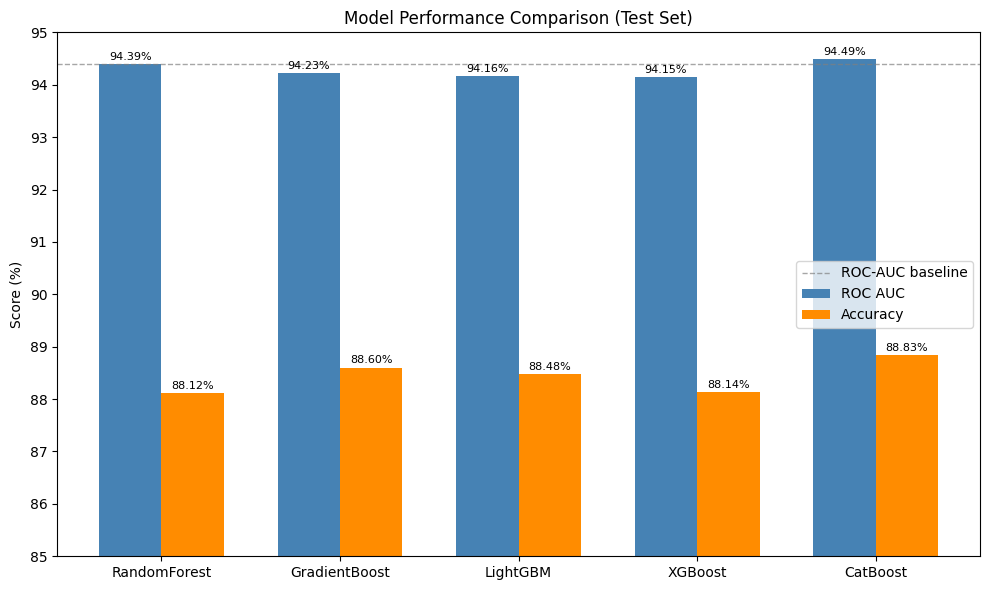

In [ ]:
# TO RUN
models = ['RandomForest', 'GradientBoost', 'LightGBM', 'XGBoost', 'CatBoost']
aucs = [100 * roc_auc_clean_rf,
        100 * roc_auc_clean_gbm,
        100 * roc_auc_clean_lgb,
        100 * roc_auc_clean_xgb,
        100 * roc_auc_clean_cb]

accs = [100 * acc_clean_rf,
        100 * acc_clean_gbm,
        100 * acc_clean_lgb,
        100 * acc_clean_xgb,
        100 * acc_clean_cb]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10,6))
bars1 = ax.bar(x - width/2, aucs, width, label='ROC AUC', color='steelblue')
bars2 = ax.bar(x + width/2, accs, width, label='Accuracy', color='darkorange')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison (Test Set)')
ax.set_xticks(x)
ax.set_yticks(np.arange(84,96))
ax.set_xticklabels(models)
for bar in bars1 + bars2:
    h = bar.get_height()
    ax.annotate(f'{h:.2f}%', xy=(bar.get_x() + bar.get_width()/2, h),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)
ax.set_ylim(85, 95)
ax.axhline(y=100 * roc_auc_clean_rf, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='ROC-AUC baseline')
ax.legend()
plt.tight_layout()
plt.show()

We now plot the ROC curve, the area under which coincides with the evaluation metric we used, _i.e._ the ROC-AUC. Recall that the larger the area, the better; an area of 0.5 corresponds to a random guess, and of 1 to a perfect classification. We zoom on the relevant points on this curve, _i.e._ those where the probability ofa false positive is under the threshold of 20%, as would be the case for some scientific experiments.

to do: comment??

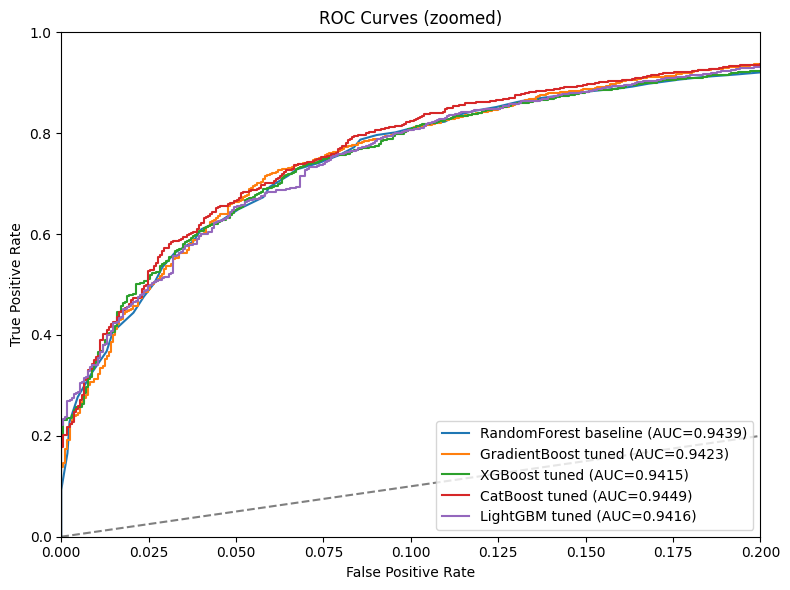

In [ ]:
# TO RUN
fig, ax = plt.subplots(figsize=(8,6))
for name, y_prob, auc_val in [('RandomForest baseline', y_prob_rf, roc_auc_clean_rf),
                              ('GradientBoost tuned', y_prob_gbm, roc_auc_clean_gbm),
                              ('XGBoost tuned', y_prob_xgb, roc_auc_clean_xgb),
                              ('CatBoost tuned', y_prob_cb, roc_auc_clean_cb),
                              ('LightGBM tuned', y_prob_lgb, roc_auc_clean_lgb)]:
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0,1],[0,1],'k--', alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves (zoomed)')
ax.set_xlim(0., 0.2)
ax.set_ylim(0, 1.0)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

We now plot Optuna's optimization history for the three models. We can observe how fluctuations in ROC-AUC metric become smaller while progressing with iterations, which indicates an effective exploration of the hyperparameter space.

We further note how LightGBM's fluctuations are smaller. The reason is that LightGBM’s leaf‑wise growth with GOSS and EFB makes it efficiently exploit informative samples, so its performance is less sensitive to small hyperparameter changes. Its default regularisation is already strong, and the algorithm converges quickly to a good solution, reducing variance across Optuna trials.

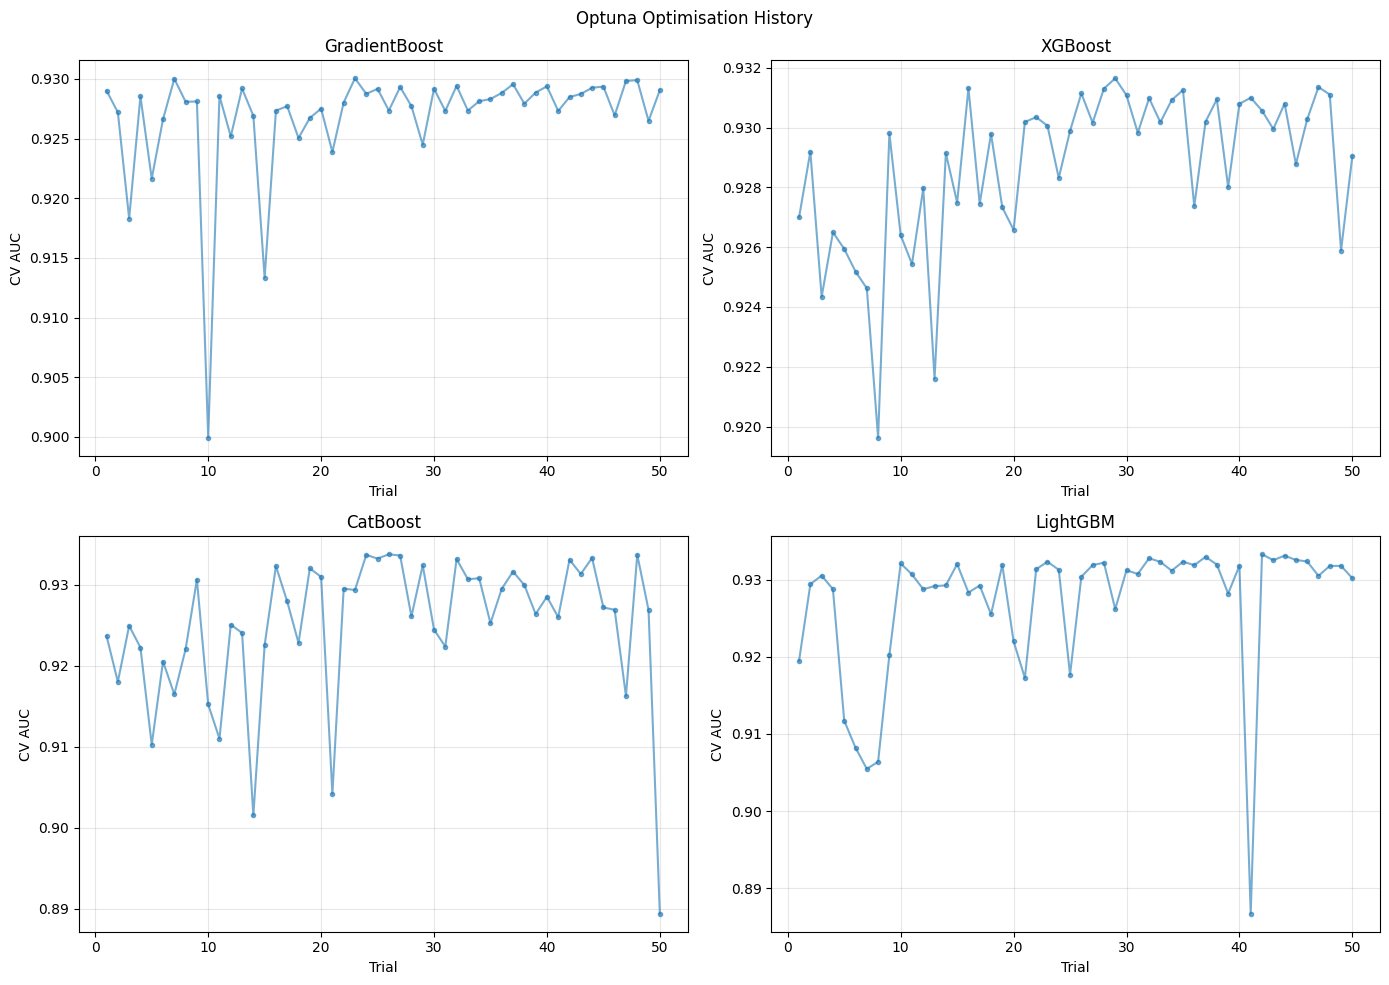

In [ ]:
# TO RUN
def plot_convergence(study, name, ax):
    trials = study.trials
    values = [t.value for t in trials if t.state == optuna.trial.TrialState.COMPLETE]
    ax.plot(range(1, len(values)+1), values, marker='.', alpha=0.6)
    ax.set_title(name)
    ax.set_xlabel('Trial')
    ax.set_ylabel('CV AUC')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_convergence(study_gbm, 'GradientBoost', axes[0, 0])
plot_convergence(study_xgb, 'XGBoost', axes[0, 1])
plot_convergence(study_cb,  'CatBoost',    axes[1, 0])
plot_convergence(study_lgb, 'LightGBM',    axes[1, 1])
fig.suptitle('Optuna Optimisation History')
plt.tight_layout()
plt.show()

We also plot the SHAP score for the best model, _i.e._ the XGBoost tuned model.

SHAP values measure how much each feature pushes a prediction away from the average prediction. For tree models, TreeSHAP computes these by tracking how splits change the expected output as it traverses each path, averaging the feature's contribution over all trees. The result is an additive explanation where each feature's SHAP value plus the baseline equals the model's prediction for that instance. (Therefore: one point = one feature of one sample from test set, from the positive class).

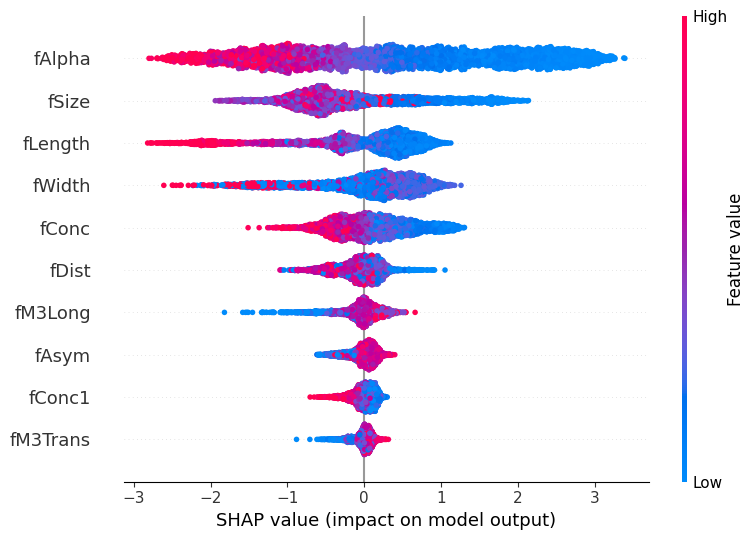

In [ ]:
#TO RUN
explainer_xgb = shap.TreeExplainer(best_model_xgb) # ie. tuned XGBoost
shap_values_xgb = explainer_xgb.shap_values(X_test)  # subsample for speed
shap.summary_plot(shap_values_xgb, X_test, feature_names=feature_names)

## Neural network comparison

We now implement a simple neural network (NN), and tune it accordin to a similar in order to compare

#### Optuna optimisation

In [ ]:
# TO RUN
scaler = StandardScaler() # standardize input data beforehand
X_training_sc = scaler.fit_transform(X_training)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

In [ ]:
spe=len(X_training) // 256 + 1

In [ ]:
# TO RUN
id=X_training.shape[1]

In [ ]:
print(id)

10


In [ ]:
print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# TO RUN ON GPU?
def objective_nn(trial,input_dim=id):
    # Hyperparameters to tune
    units1 = trial.suggest_int('units1', 32, 128, step=32)
    units2 = trial.suggest_int('units2', 16, 64, step=16)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.6)
    l2_reg = trial.suggest_float('l2_reg', 1e-6, 1e-3, log=True)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    noise_std = trial.suggest_float('noise_std', 0.0, 0.2)

    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    model.add(GaussianNoise(noise_std))
    model.add(Dense(units1, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(units2, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=[AUC(curve='ROC', name='auc')],
        steps_per_execution=spe)

    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10,
                               restore_best_weights=True)

    history = model.fit(
        X_training_sc, Y_training,
        validation_data=(X_val_sc, Y_val),
        epochs=100, batch_size=256, callbacks=[early_stop], verbose=0
    )

    # Return the best validation AUC achieved during training
    return max(history.history['val_auc'])

# ------------------------------------------------------------
# 2. Run the Optuna study
# ------------------------------------------------------------
study_nn = optuna.create_study(direction='maximize')
i = time.time()
study_nn.optimize(objective_nn, n_trials=50, show_progress_bar=True)
elapsed_nn_tune = time.time() - i
print(f"NN Optuna tuning completed in {elapsed_nn_tune:.1f} seconds.")
print("Best NN hyperparameters:", study_nn.best_params)

  0%|          | 0/50 [00:00<?, ?it/s]

NN Optuna tuning completed in 1230.4 seconds.
Best NN hyperparameters: {'units1': 96, 'units2': 48, 'dropout_rate': 0.17038720815165248, 'l2_reg': 1.2269685012952172e-05, 'learning_rate': 0.0030936986901883095, 'noise_std': 0.007052255580963361}


In [ ]:
best_nn_params = study_nn.best_params

joblib.dump(study_nn, 'study_nn.pkl')
joblib.dump(best_nn_params, 'best_nn_params.pkl')

['best_nn_params.pkl']

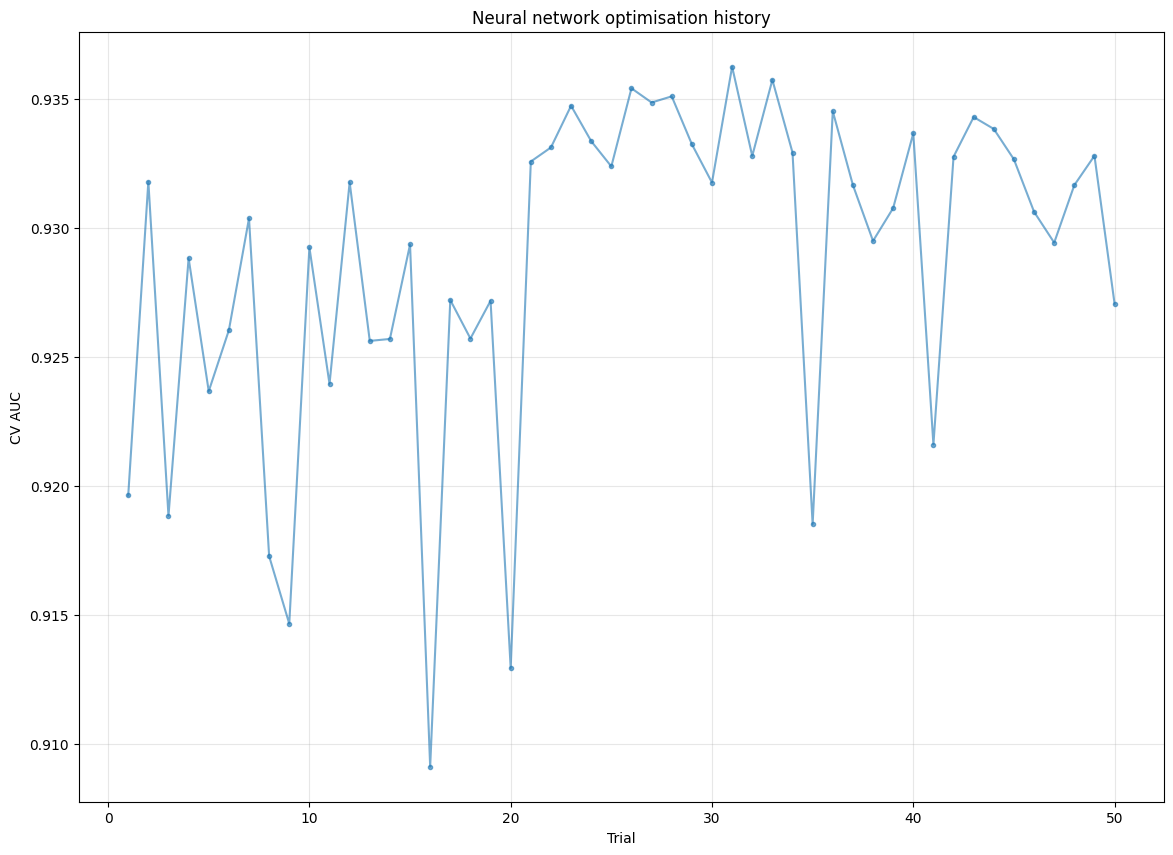

In [ ]:
# TO RUN
fig, ax = plt.subplots(figsize=(14, 10))
plot_convergence(study_nn, 'Neural network optimisation history', ax)

In [ ]:
# TO RUN
optuna.visualization.plot_param_importances(study_nn).show()

In [ ]:
# note: by default hypeparams are the best found ones
def build_nn_model(input_dim,
                units1=best_nn_params['units1'],
                units2=best_nn_params['units2'],
                dropout_rate=best_nn_params['dropout_rate'],
                l2_reg=best_nn_params['l2_reg'],
                noise_std=best_nn_params['noise_std'],
                learning_rate=best_nn_params['learning_rate']):

    model = Sequential()
    model.add(GaussianNoise(noise_std, input_shape=(input_dim,)))
    model.add(Dense(units1, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(units2, activation='relu', kernel_regularizer=l2(l2_reg)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate),
        loss='binary_crossentropy',
        metrics=[AUC(curve='ROC', name='auc')] # AUC class with curve parameter
    )
    return model

In [ ]:
simple_nn=build_nn_model(input_dim=id)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [ ]:
simple_nn.summary()

Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise_50               │ (None, 10)             │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_150 (Dense)               │ (None, 96)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_100         │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_100 (Dropout)           │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_151 (Dense)               │ (None, 48)             │         4,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_101         │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_101 (Dropout)           │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_152 (Dense)               │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,049 (23.63 KB)

 Non-trainable params: 288 (1.12 KB)

In [ ]:
#dense, dropout, dense, dropout, dense

In [ ]:
early_stop = EarlyStopping(
    monitor='val_auc', #AUC(curve='ROC'),
    mode='max',
    patience=10,
    restore_best_weights=True
)

In [ ]:
i=time.time()
history = simple_nn.fit(
    X_training_sc, Y_training,
    validation_data=(X_val_sc, Y_val),
    epochs=100, # but early stopping
    batch_size=256,
    callbacks=[early_stop],
    verbose=0
)
f=time.time()
elapsed_nn=f-i
print(f"Training completed in {elapsed_nn:.1f} seconds.")

Training completed in 23.1 seconds.


In [ ]:
test_loss, roc_auc_clean_nn = simple_nn.evaluate(X_test_sc, Y_test, verbose=0)
print(f"\nTest ROC AUC: {roc_auc_clean_nn:.4f}")


Test ROC AUC: 0.9419


In [ ]:
joblib.dump({
    'history': history,
    'elapsed_nn': elapsed_nn,
    'roc_auc_clean_nn': roc_auc_clean_nn
}, 'nn_final.pkl')
simple_nn.save('nn_model.h5')


In [ ]:
clean_metrics = {
    'rf':  {'auc': roc_auc_clean_rf,  'acc': acc_clean_rf,  'err': err_clean_rf},
    'gbm': {'auc': roc_auc_clean_gbm, 'acc': acc_clean_gbm, 'err': err_clean_gbm},
    'xgb': {'auc': roc_auc_clean_xgb, 'acc': acc_clean_xgb, 'err': err_clean_xgb},
    'cb':  {'auc': roc_auc_clean_cb,  'acc': acc_clean_cb,  'err': err_clean_cb},
    'lgb': {'auc': roc_auc_clean_lgb, 'acc': acc_clean_lgb, 'err': err_clean_lgb},
    'nn':  {'auc': roc_auc_clean_nn}
}
joblib.dump(clean_metrics, 'clean_metrics.pkl')

joblib.dump({
    'xgb': best_model_xgb,
    'cat': final_model_cb,
    'lgb': final_model_lgb,
    'gbm': study_gbm.best_params
}, 'best_params.pkl')

['best_params.pkl']

In [ ]:
# TO RUN
# --- Compute predictions (instead of loading) ---
y_pred_rf   = rf.predict(X_test)
y_prob_rf   = rf.predict_proba(X_test)[:, 1]
y_pred_gbm  = best_gbm.predict(X_test)
y_prob_gbm  = best_gbm.predict_proba(X_test)[:, 1]
y_pred_xgb  = best_model_xgb.predict(X_test)
y_prob_xgb  = best_model_xgb.predict_proba(X_test)[:, 1]
y_pred_cb   = final_model_cb.predict(X_test)
y_prob_cb   = final_model_cb.predict_proba(X_test)[:, 1]
y_pred_lgb  = final_model_lgb.predict(X_test)
y_prob_lgb  = final_model_lgb.predict_proba(X_test)[:, 1]

y_pred_nn   = (simple_nn.predict(X_test_sc) > 0.5).astype(int).ravel()
y_prob_nn   = simple_nn.predict(X_test_sc).ravel()

## Some model comparisons

#### Confusion matrices

149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


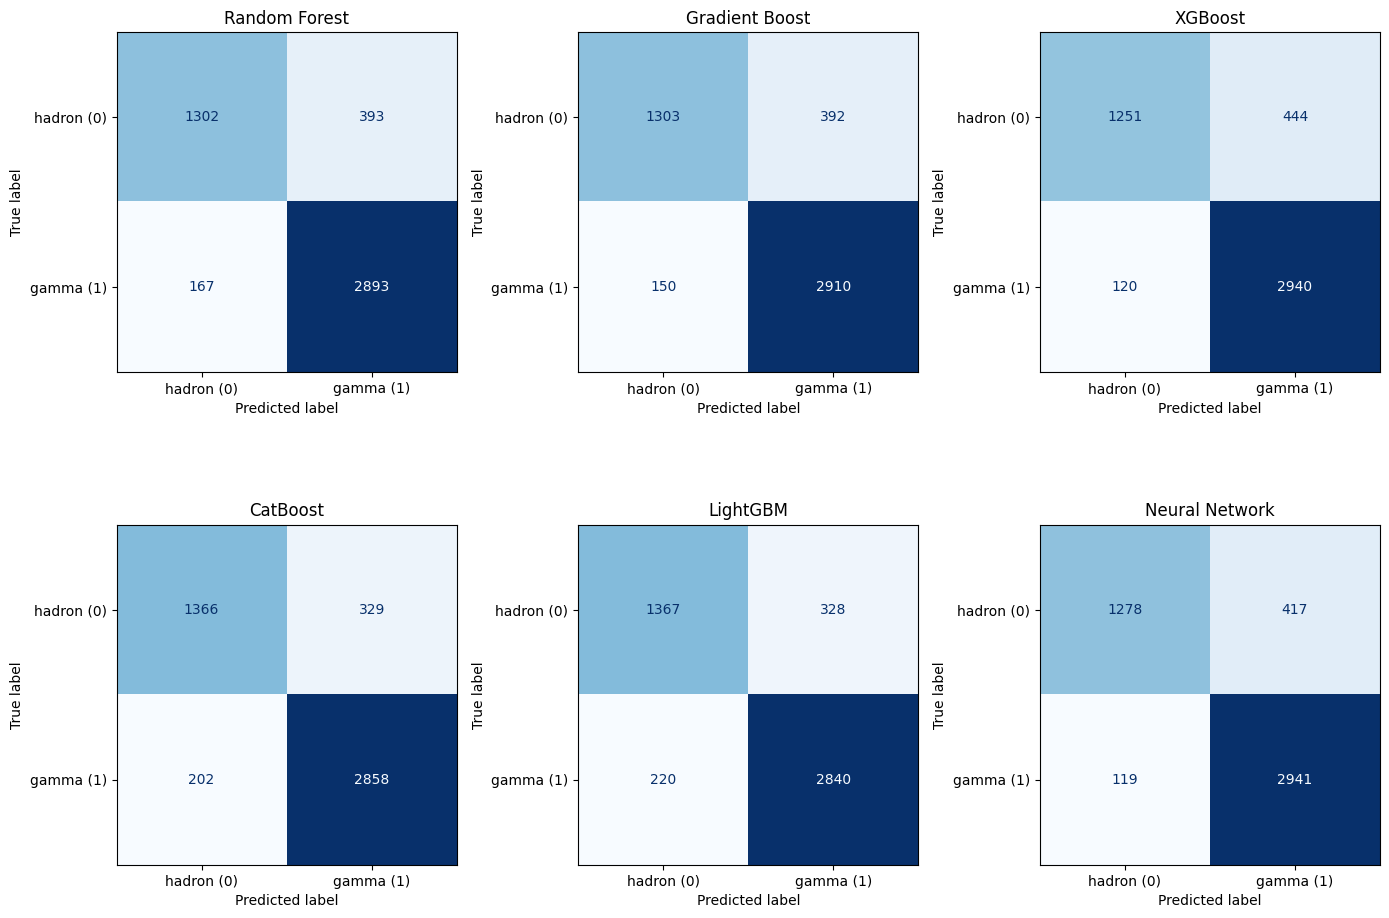

In [ ]:
# Confusion matrices for all models
from sklearn.metrics import ConfusionMatrixDisplay

# NN predictions (binary)
y_pred_nn = (simple_nn.predict(X_test_sc) > 0.5).astype(int).ravel()

models_cm = [
    ('Random Forest', y_pred_rf),
    ('Gradient Boost', y_pred_gbm),
    ('XGBoost', y_pred_xgb),
    ('CatBoost', y_pred_cb),
    ('LightGBM', y_pred_lgb),
    ('Neural Network', y_pred_nn)
]

fig, axes = plt.subplots(2, 3, figsize=(14, 10))
axes = axes.flatten()

for ax, (name, y_pred) in zip(axes, models_cm):
    cm = confusion_matrix(Y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['hadron (0)','gamma (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
# to do: comment??

#### Hyperparameter importance (Optuna)

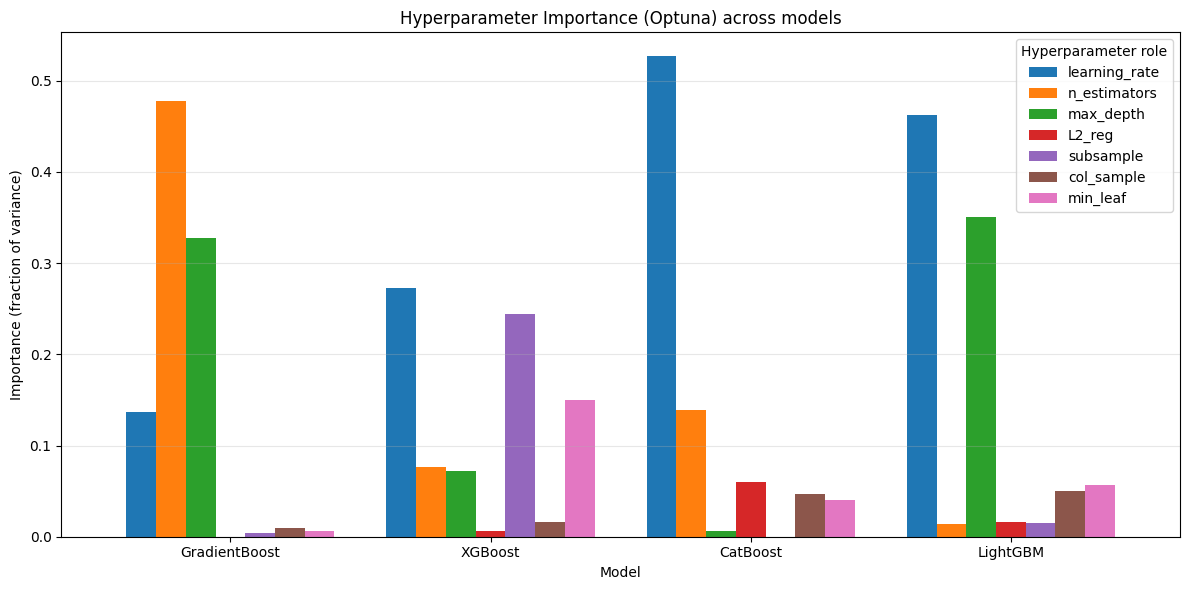

In [ ]:
import optuna.importance

studies = [study_gbm, study_xgb, study_cb, study_lgb]
model_names = ['GradientBoost', 'XGBoost', 'CatBoost', 'LightGBM']

# Map raw parameter names to common roles
param_role = {
    # GBM
    'learning_rate': 'learning_rate',
    'n_estimators': 'n_estimators',
    'max_depth': 'max_depth',
    'subsample': 'subsample',
    'max_features': 'col_sample',
    'min_samples_leaf': 'min_leaf',
    # XGBoost
    'gamma': None, 'reg_lambda': 'L2_reg',
    'colsample_bytree': 'col_sample',
    'min_child_weight': 'min_leaf',
    # CatBoost
    'iterations': 'n_estimators',
    'depth': 'max_depth',
    'l2_leaf_reg': 'L2_reg',
    'random_strength': None,
    'bagging_temperature': None,
    'scale_pos_weight': None,
    'colsample_bylevel': 'col_sample',
    'min_data_in_leaf': 'min_leaf',
    # LightGBM
    'reg_lambda': 'L2_reg',
    'min_child_samples': 'min_leaf',
    # parameters not listed are ignored (e.g., min_samples_split, gamma)
}

roles = ['learning_rate', 'n_estimators', 'max_depth', 'L2_reg',
         'subsample', 'col_sample', 'min_leaf']

data = {model: {role: 0.0 for role in roles} for model in model_names}
for study, model in zip(studies, model_names):
    importances = optuna.importance.get_param_importances(study)
    for param, imp in importances.items():
        role = param_role.get(param)
        if role in data[model]:
            data[model][role] += imp

df_imp = pd.DataFrame(data).T   # models as rows, parameters as columns
ax = df_imp.plot(kind='bar', figsize=(12, 6), width=0.8)
ax.set_title('Hyperparameter Importance (Optuna) across models')
ax.set_ylabel('Importance (fraction of variance)')
ax.set_xlabel('Model')
ax.legend(title='Hyperparameter role')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

to do: comment?

In [ ]:
#HEREEEEEEEEEEEEEEEEEEEEEEEEEEEEE
update_elapsed('rf_train', elapsed_rf)


In [ ]:

update_elapsed('gbm_optuna', elapsed_gbm)

In [ ]:
update_elapsed('xgb_optuna', elapsed_xgb)

In [ ]:
update_elapsed('cb_optuna', elapsed_cb)

In [ ]:
update_elapsed('lgb_optuna', elapsed_lgb)

In [ ]:
update_elapsed('nn_optuna', elapsed_nn_tune)

In [ ]:
update_elapsed('nn_final', elapsed_nn)

#### SHAP values

In [ ]:
# 1. Random Forest (TreeExplainer)
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X_test)[:, :, 1]  # class 1 (positive)
mean_abs_shap_rf = np.abs(shap_values_rf).mean(axis=0)

# 2. XGBoost (already computed earlier, but recompute for consistency)
explainer_xgb = shap.TreeExplainer(best_model_xgb)
shap_values_xgb = explainer_xgb.shap_values(X_test)
mean_abs_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)

# 3. CatBoost (TreeExplainer works)
explainer_cb = shap.TreeExplainer(final_model_cb)
shap_values_cb = explainer_cb.shap_values(X_test)  # CatBoost returns list for classes
mean_abs_shap_cb = np.abs(shap_values_cb).mean(axis=0)

# Use a small background sample for DeepExplainer (NN)
background_nn = X_training_sc[:100]


In [ ]:
# 4. Neural Network (DeepExplainer)
# Need to ensure model is in train mode? DeepExplainer uses background.
explainer_nn = shap.DeepExplainer(simple_nn, background_nn)
shap_values_nn = explainer_nn.shap_values(X_test_sc[:200])[:, :, 0]  # (200, 10)  # use subset for speed
# shap_values_nn is a list for binary: [negative_shap, positive_shap]
mean_abs_shap_nn = np.abs(shap_values_nn).mean(axis=0)   # class 1

# Collect into DataFrame
shap_importance_df = pd.DataFrame({
    'RandomForest': mean_abs_shap_rf,
    'XGBoost': mean_abs_shap_xgb,
    'CatBoost': mean_abs_shap_cb,
    'NeuralNet': mean_abs_shap_nn
}, index=feature_names)

# normalise each column to sum to 1
shap_importance_norm = shap_importance_df.div(shap_importance_df.sum(axis=0), axis=1)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning:

Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1850
Received: inputs=['Tensor(shape=(100, 10))']

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1850
Received: inputs=['Tensor(shape=(200, 10))']



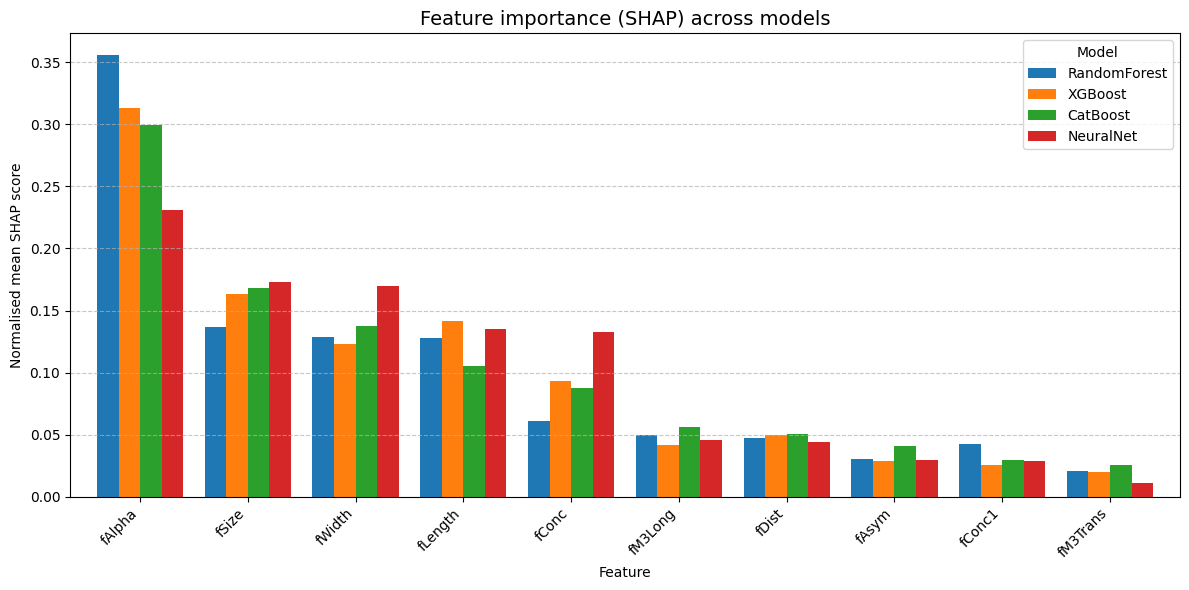

In [ ]:
row_means = shap_importance_norm.mean(axis=1)
shap_importance_norm_sorted = shap_importance_norm.loc[row_means.sort_values().index][::-1]

fig, ax = plt.subplots(figsize=(12, 6))
shap_importance_norm_sorted.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Feature importance (SHAP) across models', fontsize=14)
ax.set_ylabel('Normalised mean SHAP score')
ax.set_xlabel('Feature')
ax.set_xticklabels(shap_importance_norm_sorted.index, rotation=45, ha='right')
ax.legend(title='Model')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump(explainer_xgb, 'shap_explainer_xgb.pkl')
joblib.dump({
    'feature_names': feature_names,
    'rf_shap_mean_abs':  mean_abs_shap_rf,
    'xgb_shap_mean_abs': mean_abs_shap_xgb,
    'cb_shap_mean_abs':  mean_abs_shap_cb,
    'nn_shap_mean_abs':  mean_abs_shap_nn,
    'shap_values_rf':  shap_values_rf,
    'shap_values_xgb': shap_values_xgb,
    'shap_values_cb':  shap_values_cb,
    'shap_values_nn':  shap_values_nn
}, 'shap_feature_importance.pkl')
joblib.dump(shap_importance_norm, 'shap_importance_norm.pkl')

['shap_importance_norm.pkl']

## Effects of smaller / noisy training datasets

#### Reduced-size dataset

In [ ]:
# --- Learning Curve: Test ROC‑AUC vs Training Set Size ---
# Uses tuned Optuna params for XGBoost, CatBoost, LightGBM

# Best params from  Optuna studies (hardcoded for reproducibility)
best_model_xgb = {
    'booster': 'gbtree', 'objective': 'binary:logistic', 'n_jobs': -1,
    'tree_method': 'hist', 'device':'cuda', 'random_state': 42, 'eval_metric': 'auc',
    'early_stopping_rounds': 50, 'verbosity': 0,
    **study_xgb.best_params
}
final_model_cb = {
    'loss_function': 'Logloss', 'eval_metric': 'AUC', 'task_type': 'CPU',
    'verbose': False, 'random_seed': 42, 'early_stopping_rounds': 50,
    **study_cb.best_params
}
final_model_lgb = {
    'boosting_type': 'gbdt', 'objective': 'binary', 'metric': 'auc',
    'n_jobs': -1, 'random_state': 42, 'verbosity': -1,
    'bagging_freq': 1, 'device': 'gpu',
    **study_lgb.best_params
}

In [ ]:
# TO RUN
# Fractions of the training set to use
fracs = np.linspace(0.1, 0.9, 9)

In [ ]:
lc_auc_xgb, lc_auc_cat, lc_auc_lgb, lc_auc_nn = [], [], [], []
i=time.time()

for frac in fracs:
    # Subsample the training data (stratified)
    X_sub, _, y_sub, _ = train_test_split(
        X_training, Y_training, train_size=float(frac), stratify=Y_training, random_state=42
    )
    # Further split off a validation subset (10%) for early stopping
    X_tr, X_val_sub, y_tr, y_val_sub = train_test_split(
        X_sub, y_sub, test_size=0.1, stratify=y_sub, random_state=42
    )

    # XGBoost
    model_xgb = xgb.XGBClassifier(**best_model_xgb)
    model_xgb.fit(X_tr, y_tr, eval_set=[(X_val_sub, y_val_sub)], verbose=False)
    lc_auc_xgb.append(roc_auc_score(Y_test, model_xgb.predict_proba(X_test)[:, 1]))

    # CatBoost
    model_cat = cb.CatBoostClassifier(**{k:v for k,v in final_model_cb.items() if k != 'early_stopping_rounds'})  # clean up
    model_cat.fit(X_tr, y_tr, eval_set=[(X_val_sub, y_val_sub)], early_stopping_rounds=50, verbose=False)
    lc_auc_cat.append(roc_auc_score(Y_test, model_cat.predict_proba(X_test)[:, 1]))

    # LightGBM
    model_lgb = lgb.LGBMClassifier(**final_model_lgb)
    model_lgb.fit(X_tr, y_tr, eval_set=[(X_val_sub, y_val_sub)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
    lc_auc_lgb.append(roc_auc_score(Y_test, model_lgb.predict_proba(X_test)[:, 1]))

    # Scale data for NN
    scaler_nn = StandardScaler()
    X_tr_sc = scaler_nn.fit_transform(X_tr)
    X_val_sub_sc = scaler_nn.transform(X_val_sub)
    X_test_sc_lc = scaler_nn.transform(X_test)   # re‑scale test with this fraction's scaler

    m1=time.time()
    partial_elapsed_1=m1-i
    print(f"Reduced dataset level {frac} completed in {partial_elapsed_1:.1f} seconds for boosted models - now doing NN for this level")

    # Build fresh NN
    model_nn = build_nn_model(input_dim=id)
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)

    model_nn.fit(X_tr_sc, y_tr, validation_data=(X_val_sub_sc, y_val_sub),
                 epochs=100, batch_size=256, callbacks=[early_stop], verbose=0)

    lc_auc_nn.append(roc_auc_score(Y_test, model_nn.predict(X_test_sc_lc).ravel()))#[:, 1]))
    m=time.time()
    partial_elapsed_2=m-i
    print(f"Reduced dataset level {frac} completed in {partial_elapsed_2:.1f} seconds")

f=time.time()
elapsed_red=f-i
print(f"Reduced dataset experiment completed in {elapsed_red:.1f} seconds.")

In [ ]:
joblib.dump({
    'train_sizes': train_sizes,
    'lc_auc_xgb': lc_auc_xgb, 'lc_auc_cat': lc_auc_cat,
    'lc_auc_lgb': lc_auc_lgb, 'lc_auc_nn': lc_auc_nn,
    'elapsed_red': elapsed_red,
    'partial_times': {'boosted': partial_elapsed_1, 'nn': partial_elapsed_2}
}, 'learning_curve_results.pkl')

update_elapsed('learning_curve', elapsed_red)

In [ ]:
# TO RUN
# Plot
train_sizes = [int(frac * len(Y_training)) for frac in fracs]
plt.figure(figsize=(8, 5))
plt.plot(train_sizes, lc_auc_xgb, 'o-', label='XGBoost', color='blue')
plt.plot(train_sizes, lc_auc_cat, 'o-', label='CatBoost', color='green')
plt.plot(train_sizes, lc_auc_lgb, 'o-', label='LightGBM', color='azure')
plt.plot(train_sizes, lc_auc_nn, 'o-', label='Neural network', color='gray')
full_size = len(Y_training)
plt.scatter(full_size, roc_auc_clean_xgb, color='blue',   marker='*', s=120, zorder=5)
plt.scatter(full_size, roc_auc_clean_cb,  color='green',  marker='*', s=120, zorder=5)
plt.scatter(full_size, roc_auc_clean_lgb, color='azure', marker='*', s=120, zorder=5)
plt.scatter(full_size, roc_auc_clean_nn,          color='gray', marker='*', s=120, zorder=5)   # NN
# dummy scatter for legend
#plt.scatter([], [], color='gray', marker='*', s=80, label='Full training set')
plt.xlabel('Training set size')
plt.ylabel('Test ROC‑AUC')
plt.title('Learning Curve (fixed Optuna params)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Noisy dataset

In [ ]:
# ---- Robustness to Gaussian feature noise ----
def rigorous_augmentation(X, y, noise_level=0.01, multiplier=2):
  """Add Gaussian noise (scaled by feature std) and optionally multiply the dataset."""
  X_augmented_list = [X]
  y_augmented_list = [y]
  stds = np.std(X, axis=0)
  for _ in range(multiplier - 1):
      noise = np.random.normal(0, stds * noise_level, size=X.shape)
      X_noisy = X + noise
      X_augmented_list.append(X_noisy)
      y_augmented_list.append(y)
  return np.vstack(X_augmented_list), np.concatenate(y_augmented_list)

In [ ]:
noise_levels_high = np.linspace(0.2, 1., 4)
noise_levels_low = np.logspace(-2., -1., 5)

noise_levels=np.concatenate([noise_levels_low, noise_levels_high])

auc_drop_xgb, auc_drop_cb, auc_drop_lgb, auc_drop_nn = [], [], [], []

i=time.time()
for p in noise_levels:
    X_aug, y_aug = rigorous_augmentation(X_training, Y_training, noise_level=p)

    # XGBoost
    m_xgb = xgb.XGBClassifier(**best_model_xgb)
    m_xgb.fit(X_aug, y_aug, eval_set=[(X_val, Y_val)], verbose=False)
    auc_xgb_noise = roc_auc_score(Y_test, m_xgb.predict_proba(X_test)[:, 1])
    auc_drop_xgb.append(roc_auc_clean_xgb - auc_xgb_noise)

    # CatBoost (early_stopping_rounds belongs to fit, not constructor)
    cat_params_clean = {k: v for k, v in final_model_cb.items() if k != 'early_stopping_rounds'}
    m_cb = cb.CatBoostClassifier(**cat_params_clean)
    m_cb.fit(X_aug, y_aug, eval_set=[(X_val, Y_val)],
             early_stopping_rounds=50, verbose=False)
    auc_cb = roc_auc_score(Y_test, m_cb.predict_proba(X_test)[:, 1])
    auc_drop_cb.append(roc_auc_clean_cb - auc_cb)

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**final_model_lgb)
    m_lgb.fit(X_aug, y_aug, eval_set=[(X_val, Y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    auc_lgb = roc_auc_score(Y_test, m_lgb.predict_proba(X_test)[:, 1])
    auc_drop_lgb.append(roc_auc_clean_lgb - auc_lgb)

    m1=time.time()
    partial_elapsed_3=m1-i
    print(f"Noise level {p:.2f} completed in {partial_elapsed_3:.1f} seconds for boosted models - now doing NN for this level")

    # Neural network (fresh model each time)
    # Scale the augmented training data and the original test set
    scaler_noise = StandardScaler()
    X_aug_sc = scaler_noise.fit_transform(X_aug) # train on noisy dataset
    X_test_sc_lc = scaler_noise.transform(X_test) # test on clean dataset
    X_val_sc_nn = scaler_noise.transform(X_val) # validate (ie. early stopping) during training on clean dataset - standard practice

    nn_model = build_nn_model(input_dim=id)   # creates a new compiled model
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10,
                               restore_best_weights=True)
    nn_model.fit(X_aug_sc, y_aug,
                 validation_data=(X_val_sc_nn, Y_val),
                 epochs=100, batch_size=256, callbacks=[early_stop], verbose=0)
    auc_nn = nn_model.evaluate(X_test_sc_lc, Y_test, verbose=0)[1]   # returns [loss, auc]

    auc_drop_nn.append(roc_auc_clean_nn - auc_nn)

    m=time.time()
    partial_elapsed_10=m-i
    print(f"Noise level {p:.2f} completed after {partial_elapsed_10:.1f} seconds")
f=time.time()
elapsed_feat=f-i
print(f"Feature‑noise robustness experiment finished in {elapsed_feat:.1f} seconds.")

In [ ]:
joblib.dump({
    'noise_levels_feat': noise_levels,
    'auc_drop_xgb_feat': auc_drop_xgb,
    'auc_drop_cb_feat': auc_drop_cb,
    'auc_drop_lgb_feat': auc_drop_lgb,
    'auc_drop_nn_feat': auc_drop_nn,
    'elapsed_feat': elapsed_feat,
    'partial_times': {'boosted': partial_elapsed_3, 'nn': partial_elapsed_10}
}, 'feature_noise_results.pkl')

update_elapsed('feature_noise', elapsed_feat)

In [ ]:
# Plot AUC degradation

plt.figure(figsize=(8, 5))
plt.plot(noise_levels, -100*np.asarray(auc_drop_xgb), 'o-', label='XGBoost') # "-" for better visualisation
plt.plot(noise_levels, -100*np.asarray(auc_drop_cb), 's-', label='CatBoost')
plt.plot(noise_levels, -100*np.asarray(auc_drop_lgb), 'd-', label='LightGBM')
plt.plot(noise_levels, -100*np.asarray(auc_drop_nn), 'v-', label='Neural Net')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No degradation')
plt.xlabel('Gaussian noise level (relative to feature std)')
plt.ylabel('Noisy AUC − Clean AUC (%)')
plt.title('Impact of Feature Noise on Model Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.xscale('log')
plt.tight_layout()
plt.show()

### Noisy most important components only

In [ ]:
"""### Noisy most important components only"""

# ---- Determine top 3 features from XGBoost built‑in importance ----
importances = best_model_xgb.feature_importances_
top_3_indices = np.argsort(importances)[-3:][::-1]
top_3_names = [feature_names[i] for i in top_3_indices]
print(f"Top 3 features (XGBoost gain): {top_3_names}")

def targeted_noise_test(X, target_indices, noise_level, stds):
    """Add Gaussian noise ONLY to specified columns of a test set copy."""
    X_noisy = np.array(X, copy=True)
    for idx in target_indices:
        noise = np.random.normal(0, stds[idx] * noise_level, size=len(X_noisy))
        X_noisy[:, idx] += noise
    return X_noisy

# Train one fresh set of models on clean data (to evaluate this experiment only)
m_xgb = xgb.XGBClassifier(**best_model_xgb)
m_xgb.fit(X_training, Y_training, eval_set=[(X_val, Y_val)], verbose=False)
cat_params_clean = {k: v for k, v in final_model_cb.items() if k != 'early_stopping_rounds'}
m_cb = cb.CatBoostClassifier(**cat_params_clean)
m_cb.fit(X_training, Y_training, eval_set=[(X_val, Y_val)], early_stopping_rounds=50, verbose=False)
m_lgb = lgb.LGBMClassifier(**final_model_lgb)
m_lgb.fit(X_training, Y_training, eval_set=[(X_val, Y_val)],
          callbacks=[lgb.early_stopping(50, verbose=False)])

# Neural network – same scaling as earlier
scaler_target = StandardScaler()
X_train_sc_t = scaler_target.fit_transform(X_training)
X_val_sc_t   = scaler_target.transform(X_val)
nn_model_t = build_nn_model(input_dim=10)
es = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)
nn_model_t.fit(X_train_sc_t, Y_training, validation_data=(X_val_sc_t, Y_val),
               epochs=100, batch_size=256, callbacks=[es], verbose=0)

# Baselines from these exact instances
base_auc_xgb = roc_auc_score(Y_test, m_xgb.predict_proba(X_test)[:, 1])
base_auc_cb  = roc_auc_score(Y_test, m_cb.predict_proba(X_test)[:, 1])
base_auc_lgb = roc_auc_score(Y_test, m_lgb.predict_proba(X_test)[:, 1])
base_auc_nn  = nn_model_t.evaluate(scaler_target.transform(X_test), Y_test, verbose=0)[1]

# Noise levels – only for evaluation, no training
noise_levels_target = np.linspace(0.1, 3.0, 10)
stds = np.std(X_test, axis=0)
auc_drop_xgb_t, auc_drop_cb_t, auc_drop_lgb_t, auc_drop_nn_t = [], [], [], []

i = time.time()
for p in noise_levels_target:
    X_test_noisy = targeted_noise_test(X_test, top_3_indices, p, stds)

    auc_xgb_noise = roc_auc_score(Y_test, m_xgb.predict_proba(X_test_noisy)[:, 1])
    auc_drop_xgb_t.append(base_auc_xgb - auc_xgb_noise)

    auc_cb_noise = roc_auc_score(Y_test, m_cb.predict_proba(X_test_noisy)[:, 1])
    auc_drop_cb_t.append(base_auc_cb - auc_cb_noise)

    auc_lgb_noise = roc_auc_score(Y_test, m_lgb.predict_proba(X_test_noisy)[:, 1])
    auc_drop_lgb_t.append(base_auc_lgb - auc_lgb_noise)

    X_test_sc_noisy = scaler_target.transform(X_test_noisy)
    auc_nn_noise = nn_model_t.evaluate(X_test_sc_noisy, Y_test, verbose=0)[1]
    auc_drop_nn_t.append(base_auc_nn - auc_nn_noise)

    print(f"Noise level {p:.2f} on top-3 features done.")

elapsed_target_feat = time.time() - i
print(f"Targeted feature noise experiment finished in {elapsed_target_feat:.1f}s.")


In [ ]:

# Plot
plt.figure(figsize=(8, 5))
plt.plot(noise_levels_target, -100*np.asarray(auc_drop_xgb_t), 'o-', label='XGBoost')
plt.plot(noise_levels_target, -100*np.asarray(auc_drop_cb_t),  's-', label='CatBoost')
plt.plot(noise_levels_target, -100*np.asarray(auc_drop_lgb_t), 'd-', label='LightGBM')
plt.plot(noise_levels_target, -100*np.asarray(auc_drop_nn_t),  'v-', label='Neural Net')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No degradation')
plt.xlabel('Gaussian noise level on top‑3 features (relative to feature std)')
plt.ylabel('Noisy AUC – Clean AUC (%)')
plt.title('Impact of Noise in Top‑3 Crucial Features (XGBoost gain)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [ ]:
# Dump results
joblib.dump({
    'noise_levels_target': noise_levels_target,
    'auc_drop_xgb_target': auc_drop_xgb_t,
    'auc_drop_cb_target':  auc_drop_cb_t,
    'auc_drop_lgb_target': auc_drop_lgb_t,
    'auc_drop_nn_target':  auc_drop_nn_t,
    'elapsed_target_feat': elapsed_target_feat,
    'top_3_indices': top_3_indices,
    'top_3_names': top_3_names
}, 'targeted_noise_results.pkl')

update_elapsed('targeted_feature_noise', elapsed_target_feat)

#### Noisy labels

In [ ]:
gbm_best = {**study_gbm.best_params} # no early_stopping_rounds here (handled by fit)

In [ ]:
noise_levels_lab = np.concatenate([np.logspace(-4, -1.2, 5), np.linspace(0.02, 0.15, 5)])
noise_levels_lab

In [ ]:
# ---- Robustness to label noise (flipped labels) ----

def inject_label_noise(y, noise_level=0.1):
    """Randomly flip a fraction of labels to the opposite class."""
    y_noisy = np.array(y).copy()
    n_samples = len(y_noisy)
    n_to_flip = int(noise_level * n_samples)
    indices_to_flip = np.random.choice(n_samples, n_to_flip, replace=False)
    unique_classes = np.unique(y_noisy)
    for idx in indices_to_flip:
        original_label = y_noisy[idx]
        possible_labels = [c for c in unique_classes if c != original_label]
        y_noisy[idx] = np.random.choice(possible_labels)
    return y_noisy

auc_drop_xgb_lab, auc_drop_cb_lab, auc_drop_lgb_lab, auc_drop_nn_lab = [], [], [], []

i=time.time()
for p in noise_levels_lab:
    y_noisy = inject_label_noise(Y_training, noise_level=p)

    # XGBoost
    m_xgb = xgb.XGBClassifier(**best_model_xgb)
    m_xgb.fit(X_training, y_noisy, eval_set=[(X_val, Y_val)], verbose=False)
    auc_xgb = roc_auc_score(Y_test, m_xgb.predict_proba(X_test)[:, 1])
    auc_drop_xgb_lab.append(roc_auc_clean_xgb - auc_xgb)

    # CatBoost (early_stopping_rounds in fit, remove from params if present)
    cat_params_clean = {k: v for k, v in final_model_cb.items() if k != 'early_stopping_rounds'}
    m_cb = cb.CatBoostClassifier(**cat_params_clean)
    m_cb.fit(X_training, y_noisy, eval_set=[(X_val, Y_val)],
             early_stopping_rounds=50, verbose=False)
    auc_cb = roc_auc_score(Y_test, m_cb.predict_proba(X_test)[:, 1])
    auc_drop_cb_lab.append(roc_auc_clean_cb - auc_cb)

    # LightGBM
    m_lgb = lgb.LGBMClassifier(**final_model_lgb)
    m_lgb.fit(X_training, y_noisy, eval_set=[(X_val, Y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    auc_lgb = roc_auc_score(Y_test, m_lgb.predict_proba(X_test)[:, 1])
    auc_drop_lgb_lab.append(roc_auc_clean_lgb - auc_lgb)

    m1=time.time()
    partial_elapsed_4=m1-i
    print(f"Noise level {p:.2f} completed in {partial_elapsed_4:.1f} seconds for boosted models - now doing NN for this level")

    # Neural network (re‑train from scratch on noisy labels)
    nn_model = build_nn_model(input_dim=id)
    early_stop = EarlyStopping(monitor='val_auc', mode='max', patience=10,
                               restore_best_weights=True)
    nn_model.fit(X_training_sc, y_noisy,
                 validation_data=(X_val_sc, Y_val),
                 epochs=100, batch_size=256, callbacks=[early_stop], verbose=0) # train on noisy labels
    auc_nn = nn_model.evaluate(X_test_sc, Y_test, verbose=0)[1]
    auc_drop_nn_lab.append(roc_auc_clean_nn - auc_nn)

    m=time.time()
    partial_elapsed_11=m-i
    print(f"Label noise {p:.2f} completed after {partial_elapsed_11:.1f} seconds")


f=time.time()
elapsed_lab=f-i
print(f"Label‑noise robustness experiment finished in {elapsed_lab:.1f} seconds.")

In [ ]:
joblib.dump({
    'noise_levels_lab': noise_levels_lab,
    'auc_drop_xgb_lab': auc_drop_xgb_lab,
    'auc_drop_cb_lab': auc_drop_cb_lab,
    'auc_drop_lgb_lab': auc_drop_lgb_lab,
    'auc_drop_nn_lab': auc_drop_nn_lab,
    'elapsed_lab': elapsed_lab,
    'partial_times': {'boosted': partial_elapsed_4, 'nn': partial_elapsed_11}
}, 'label_noise_results.pkl')

update_elapsed('label_noise', elapsed_lab)

In [ ]:
# Plot AUC drop
plt.figure(figsize=(8, 5))
plt.plot(noise_levels_lab, -100*np.asarray(auc_drop_xgb_lab), 'o-', label='XGBoost', color='blue')
plt.plot(noise_levels_lab, -100*np.asarray(auc_drop_cb_lab), 's-', label='CatBoost', color='green')
plt.plot(noise_levels_lab, -100*np.asarray(auc_drop_lgb_lab), 'd-', label='LightGBM', color='orange')
plt.plot(noise_levels_lab, -100*np.asarray(auc_drop_nn_lab), 'v-', label='Neural Net', color='purple')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No degradation')
plt.xlabel('Fraction of flipped labels')
plt.ylabel('Noisy AUC – Clean AUC (%)')
plt.title('Impact of Label Noise on Model Performance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Fewer-features datasets

We study here how performance changes by removing one feature of a time, from least to most significant (we stop at 5 removed features).
As SHAP scores are already available, we use those to determine the least significant features for each model; after removing those features, we retrain each model on this new dataset; finally, we test each model (on the datasets where, of course, those least signifant features have also been removed).

In [ ]:
# ---- Robustness to feature elimination (drops) ----
models_fe = {
    'XGBoost':      (best_model_xgb, mean_abs_shap_xgb, roc_auc_clean_xgb, xgb.XGBClassifier),
    'RandomForest': (rf,             mean_abs_shap_rf,  roc_auc_clean_rf,  RandomForestClassifier),
    'CatBoost':     (final_model_cb, mean_abs_shap_cb,  roc_auc_clean_cb,  cb.CatBoostClassifier),
}
colors = {'XGBoost':'blue', 'RandomForest':'green', 'CatBoost':'orange', 'NeuralNet':'purple'}

max_drop = 5
results_drop = {}
i = time.time()

for model_name, (model_obj, shap_vals, baseline_auc, model_cls) in models_fe.items():
    importance_order = np.argsort(shap_vals)
    drops = [0.0]   # 0 features removed
    for n_drop in range(1, max_drop + 1):
        keep_mask = np.ones(len(feature_names), dtype=bool)
        keep_mask[importance_order[:n_drop]] = False
        X_train_sub = X_training[:, keep_mask]
        X_val_sub   = X_val[:, keep_mask]
        X_test_sub  = X_test[:, keep_mask]
        m = model_cls(**model_obj.get_params())
        if model_name == 'XGBoost':
            m.fit(X_train_sub, Y_training, eval_set=[(X_val_sub, Y_val)], verbose=False)
        elif model_name == 'CatBoost':
            m.fit(X_train_sub, Y_training, eval_set=[(X_val_sub, Y_val)],
                  early_stopping_rounds=50, verbose=False)
        else:
            m.fit(X_train_sub, Y_training)
        auc = roc_auc_score(Y_test, m.predict_proba(X_test_sub)[:, 1])
        drops.append(baseline_auc - auc)
    results_drop[model_name] = drops
    print(f"{model_name} done after {(time.time()-i):.1f}s")

# Neural network
importance_order_nn = np.argsort(mean_abs_shap_nn)

drops_nn = [0.0]
for n_drop in range(1, max_drop + 1):
    keep_mask = np.ones(len(feature_names), dtype=bool)
    keep_mask[importance_order_nn[:n_drop]] = False
    X_train_sub = X_training_sc[:, keep_mask]
    X_val_sub   = X_val_sc[:, keep_mask]
    X_test_sub  = X_test_sc[:, keep_mask]
    m_nn = build_nn_model(input_dim=keep_mask.sum())
    es = EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)
    m_nn.fit(X_train_sub, Y_training, validation_data=(X_val_sub, Y_val),
             epochs=100, batch_size=256, callbacks=[es], verbose=0)
    auc = roc_auc_score(Y_test, m_nn.predict(X_test_sub).ravel())
    drops_nn.append(roc_auc_clean_nn - auc)
results_drop['NeuralNet'] = drops_nn

elapsed_feats_el = time.time() - i
print(f"Feature elimination done in {elapsed_feats_el:.1f}s")

In [ ]:
# Plot drops (as –100 * drop = 100 * (noisy – clean))
plt.figure(figsize=(8,5))
n_dropped_list = list(range(max_drop + 1))
for model_name, drops in results_drop.items():
    plt.plot(n_dropped_list, -100 * np.asarray(drops), 'o-',
             label=model_name, color=colors[model_name])
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No degradation')
plt.xlabel('Number of least important features removed (by SHAP)')
plt.ylabel('Noisy AUC – Clean AUC (%)')
plt.title('Impact of Removing Least Important Features')
plt.xticks(n_dropped_list)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
joblib.dump({
    'n_dropped_list': n_dropped_list,
    'results_drop': results_drop,
    'elapsed_feats_el': elapsed_feats_el
}, 'feature_elimination_results.pkl')

update_elapsed('feature_elim', elapsed_feats_el)

## Robustness to noise

### Effects of noisy test set

In [ ]:
"""### Effects of noisy test set"""

# Evaluate robustness by adding noise only to the test set
noise_levels_noisy_test = np.linspace(0.1, 3.0, 10)
auc_drop_xgb_ntest, auc_drop_cb_ntest, auc_drop_lgb_ntest, auc_drop_nn_ntest = [], [], [], []

# Clean baselines (the final models’ AUCs, already stored)
clean_auc_xgb = roc_auc_clean_xgb
clean_auc_cb  = roc_auc_clean_cb
clean_auc_lgb = roc_auc_clean_lgb

# Standard deviations of the test set (to scale noise properly)
stds_test = np.std(X_test, axis=0)

i = time.time()
for p in noise_levels_noisy_test:
    # Add Gaussian noise to the test features
    noise = np.random.normal(0, stds_test * p, size=X_test.shape)
    X_test_noisy = X_test + noise

    # XGBoost evaluation
    y_prob_xgb_noisy = best_model_xgb.predict_proba(X_test_noisy)[:, 1]
    auc_xgb_noise = roc_auc_score(Y_test, y_prob_xgb_noisy)
    auc_drop_xgb_ntest.append(clean_auc_xgb - auc_xgb_noise)

    # CatBoost evaluation
    y_prob_cb_noisy = final_model_cb.predict_proba(X_test_noisy)[:, 1]
    auc_cb_noise = roc_auc_score(Y_test, y_prob_cb_noisy)
    auc_drop_cb_ntest.append(clean_auc_cb - auc_cb_noise)

    # LightGBM evaluation
    y_prob_lgb_noisy = final_model_lgb.predict_proba(X_test_noisy)[:, 1]
    auc_lgb_noise = roc_auc_score(Y_test, y_prob_lgb_noisy)
    auc_drop_lgb_ntest.append(clean_auc_lgb - auc_lgb_noise)

    # Neural network evaluation – scale the noisy test with the same scaler used at training
    X_test_noisy_sc = scaler.transform(X_test_noisy)
    auc_nn_noise = simple_nn.evaluate(X_test_noisy_sc, Y_test, verbose=0)[1]
    auc_drop_nn_ntest.append(roc_auc_clean_nn - auc_nn_noise)

    print(f"Noisy test level {p:.2f} evaluated.")

elapsed_noisy_test = time.time() - i
print(f"Noisy test experiment finished in {elapsed_noisy_test:.1f} s.")



In [ ]:
# Plot
plt.figure(figsize=(8, 5))
plt.plot(noise_levels_noisy_test, -100 * np.asarray(auc_drop_xgb_ntest), 'o-', label='XGBoost')
plt.plot(noise_levels_noisy_test, -100 * np.asarray(auc_drop_cb_ntest),  's-', label='CatBoost')
plt.plot(noise_levels_noisy_test, -100 * np.asarray(auc_drop_lgb_ntest), 'd-', label='LightGBM')
plt.plot(noise_levels_noisy_test, -100 * np.asarray(auc_drop_nn_ntest),  'v-', label='Neural Net')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='No degradation')
plt.xlabel('Gaussian noise level on test set (relative to feature std)')
plt.ylabel('Noisy AUC − Clean AUC (%)')
plt.title('Robustness to Noisy Test Set (clean training)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Dump the results immediately
joblib.dump({
    'noise_levels_noisy_test': noise_levels_noisy_test,
    'auc_drop_xgb_ntest': auc_drop_xgb_ntest,
    'auc_drop_cb_ntest':  auc_drop_cb_ntest,
    'auc_drop_lgb_ntest': auc_drop_lgb_ntest,
    'auc_drop_nn_ntest':  auc_drop_nn_ntest,
    'elapsed_noisy_test': elapsed_noisy_test
}, 'noisy_test_results.pkl')

update_elapsed('noisy_test', elapsed_noisy_test)

## Time performance comparison

In [ ]:
# Total times (Optuna search + final training) – NN includes its final fit
times = [elapsed_rf, elapsed_gbm, elapsed_xgb, elapsed_cb, elapsed_lgb,
         elapsed_nn_tune + elapsed_nn]
aucs  = [roc_auc_clean_rf, roc_auc_clean_gbm, roc_auc_clean_xgb,
         roc_auc_clean_cb, roc_auc_clean_lgb, roc_auc_clean_nn]
labels = ['RF', 'GBM', 'XGBoost', 'CatBoost', 'LightGBM', 'NN']

plt.figure(figsize=(8,6))
for x, y, lab in zip(times, aucs, labels):
    plt.scatter(x, y, s=100, zorder=5)
    plt.text(x+1, y, lab, fontsize=9)

# Pareto front (models not dominated in both time and AUC)
order = np.argsort(times)
best_auc = -np.inf
p_t, p_a = [], []
for i in order:
    if aucs[i] > best_auc:
        best_auc = aucs[i]
        p_t.append(times[i])
        p_a.append(aucs[i])
plt.plot(p_t, p_a, 'k--', alpha=0.5, label='Pareto front')

plt.xlabel('Total optimisation + training time (s)')
plt.ylabel('Test ROC‑AUC')
plt.title('Model Performance vs. Computational Cost')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Training time comparison
# ============================================================

experiments = ['GBM\nOptuna','XGB\nOptuna','CB\nOptuna','LGBM\nOptuna',
               'NN\n(single)','Learning\nCurve','Feature\nNoise','Label\nNoise','Feature\nElim.']
times = [elapsed_gbm, elapsed_xgb, elapsed_cb, elapsed_lgb,
         elapsed_nn, elapsed_red, elapsed_feat, elapsed_lab, elapsed_feats_el]

plt.figure(figsize=(10,5))
bars = plt.bar(experiments, times, color='skyblue', edgecolor='navy')
plt.ylabel('Wall‑clock time (seconds)')
plt.title('Training Time Comparison')
# Annotate bars
for bar, t in zip(bars, times):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{t:.0f}s', ha='center', va='bottom', fontsize=8)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# to do: retrain a "best overall" model?